In [146]:
import pandas as pd
import sys
import importlib

In [147]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [148]:
sys.path.append("../src")
import eda_utils as eda
import visualization as visual
import data_splitting as split
import preprocessing as prep
import knn as knn

importlib.reload(eda)
importlib.reload(visual)
importlib.reload(split)
importlib.reload(prep)
importlib.reload(knn)

<module 'knn' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/knn.py'>

In [149]:
dataset = pd.read_csv("../data/pf_suvs.csv")

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Exploratory Data Analysis
</h1>

In [150]:
# Columns visualization with their types
feature_types = eda.feature_types_summary(dataset)
display(feature_types.style.hide(axis="index"))

column,dtype
Precio,float64
Año,float64
Puertas,float64
Unnamed: 0,int64
Moneda,str
Título,str
Kilómetros,str
Con cámara de retroceso,str
Tipo de carrocería,str
Transmisión,str


In [151]:
# Shape of the dataset
print(f"Cantidad de filas: {dataset.shape[0]}")
print(f"Cantidad de columnas: {dataset.shape[1]}")

Cantidad de filas: 18254
Cantidad de columnas: 18


In [152]:
# Split the dataset into input features (X) and the target variable (y) to be predicted
TARGET = "Precio"

X = dataset.drop(columns = [TARGET])
y = dataset[TARGET]

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Target Analysis
</h3>

In [153]:
target_summary = eda.explore_target(y, currency = X["Moneda"])
display(target_summary.style.hide(axis="index"))

group,count,missing,missing_%,min,q1,median,mean,q3,max,std,zero_count
All,18254,0,0.000000,111.000000,31900.000000,17200000.000000,17601617.476005,29950000.000000,349500000.000000,17208100.444408,0
$,11158,0,0.000000,119000.000000,19000000.000000,27320000.000000,28774610.530113,35900000.000000,349500000.000000,12778611.327716,0
US$,7096,0,0.000000,111.000000,16000.000000,24000.000000,32810.190530,38900.000000,610000.000000,28854.448542,0


#### Análisis de la tabla

Analizamos la distribución de la variable objetivo (`Precio`) y la segmentamos por moneda de publicación. En la tabla se observa que no hay valores faltantes ni precios iguales a cero en la variable objetivo. Además, las publicaciones en pesos presentan valores mucho más altos que las publicaciones en dólares, evidenciando una diferencia de órdenes de magnitud entre ambas monedas. Por este motivo, resulta necesario unificar la unidad monetaria antes del modelado.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Analysis
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Numeric Feature Statistics
</div>

Esta tabla permite anticipar algunas decisiones importantes para el preprocesamiento. En particular, una de las variables parece comportarse como un posible identificador, ya que sus valores van desde 0 hasta la cantidad de muestras del dataset. Además, en `Año` y `Puertas` aparecen valores máximos claramente inconsistentes (`436694` y `60252`), que no son posibles en el contexto del problema. Esto sugiere la presencia de errores u outliers que deberán revisarse antes del modelado.

In [154]:
display(X.describe().T.style.format("{:,.2f}"))

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"18,254.00","9,126.50","5,269.62",0.00,"4,563.25","9,126.50","13,689.75","18,253.00"
Año,"18,254.00","2,042.80","3,217.26","1,981.00","2,016.00","2,019.00","2,024.00","436,694.00"
Puertas,"18,254.00",18.17,891.77,2.00,5.00,5.00,5.00,"60,252.00"


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Duplicate Rows Analysis
</div>

Verificamos la existencia de filas completamente duplicadas en el conjunto de datos para identificar posibles publicaciones repetidas o errores de recolección

In [155]:
eda.duplicate_rows_summary(dataset).style.hide(axis="index")

total_rows,duplicate_rows
18254,0


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Missing Values Analysis
</div>

La mayoría de las variables presentan una cantidad de valores faltantes muy reducida. La principal excepción es `Con cámara de retroceso`, con un 74,30% de datos ausentes. Por este motivo, esta variable requerirá un tratamiento particular durante el preprocesamiento.

In [156]:
eda.missing_values_summary(dataset).style.hide(axis="index")

column,missing_count,missing_percentage
Con cámara de retroceso,13563,74.300000
Color,389,2.130000
Motor,38,0.210000
Transmisión,15,0.080000


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Feature Cardinality Analysis
</div>

Calculamos la cantidad y el porcentaje de valores únicos de cada variable para identificar posibles columnas constantes, columnas indices, variables de texto y atributos categóricos de baja o alta cardinalidad.

`Unnamed: 0` tiene un valor único por fila, por lo que funciona como un identificador. En cambio, `Título` y `Descripción` muestran una alta diversidad de valores, algo esperable en columnas de texto libre escritas por los vendedores.

In [157]:
eda.unique_values_summary(dataset).style.hide(axis="index")

column,unique_values,unique_pct
Unnamed: 0,18254,100.000000
Descripción,12142,66.520000
Precio,2914,15.960000
Título,2220,12.160000
Kilómetros,2175,11.920000
Versión,2072,11.350000
Motor,271,1.480000
Modelo,137,0.750000
Color,70,0.380000
Marca,47,0.260000


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Semantic Repetitions Analysis
</div>

Analizamos las variables categóricas en busca de valores semánticamente equivalentes escritos de distintas maneras (por ejemplo, diferencias de mayúsculas, errores tipográficos o variantes de escritura). El objetivo es detectar categorías que representan el mismo concepto y deberían unificarse durante el preprocesamiento

In [158]:
categorical_columns = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de combustible",
    "Transmisión",
    "Tipo de vendedor",
]

eda.find_semantic_repetitions(dataset, columns = categorical_columns, similarity_threshold = 0.80).style.hide(axis="index")


feature,similar_values,normalized_values,total_count,n_values_grouped
Color,Blanco | Blanca | BLANCA | blanca,blanca | blanco,4818,4
Color,Negro | Negra | NEGRA,negra | negro,2830,3
Color,Dorado | MORADO,dorado | morado,191,2
Color,Amarillo | Amarrillo,amarillo | amarrillo,25,2
Color,Plata | PLATA,plata,9,2
Color,Gris plata | GRIS PLATA | GRIS PLATINO,gris plata | gris platino,5,3
Color,Marrón oscuro | Marrón claro,marron claro | marron oscuro,3,2
Color,Blanco Glaciar | BLANCO GLACIAR,blanco glaciar,2,2
Color,GRANITE CRYSTAL BC | GRANITE CRYSTA BC,granite crysta bc | granite crystal bc,2,2
Marca,Renault | Rrenault,renault | rrenault,1492,2


#### Análisis de la tabla

La tabla evidencia numerosas inconsistencias de representación, especialmente en las variables `Color`, `Marca` y `Modelo`. Se observan diferencias de capitalización (`Blanco`, `BLANCA`, `blanca`), errores tipográficos (`Renault` y `Rrenault`, `Jetour` y `Jetur`) y variantes de nomenclatura (`2008` y `208`, `X5` y `X55`). Estas inconsistencias fragmentan artificialmente las categorías y aumentan innecesariamente su cardinalidad, por lo que resulta conveniente normalizarlas antes del modelado

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Initial Graphics Analysis
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Categorical Variables
</div>

Para que el gráfico sea más legible, no incluimos `Título`, `Descripción` ni `Versión`. Como se observó en el análisis de cardinalidad, estas columnas tienen una gran cantidad de valores únicos porque contienen texto libre o descripciones específicas de cada publicación. Si se graficaran directamente, la visualización quedaría demasiado cargada y sería difícil interpretar patrones generales.

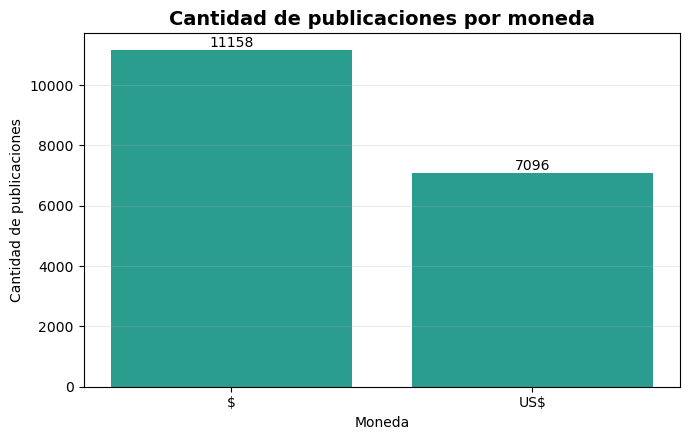

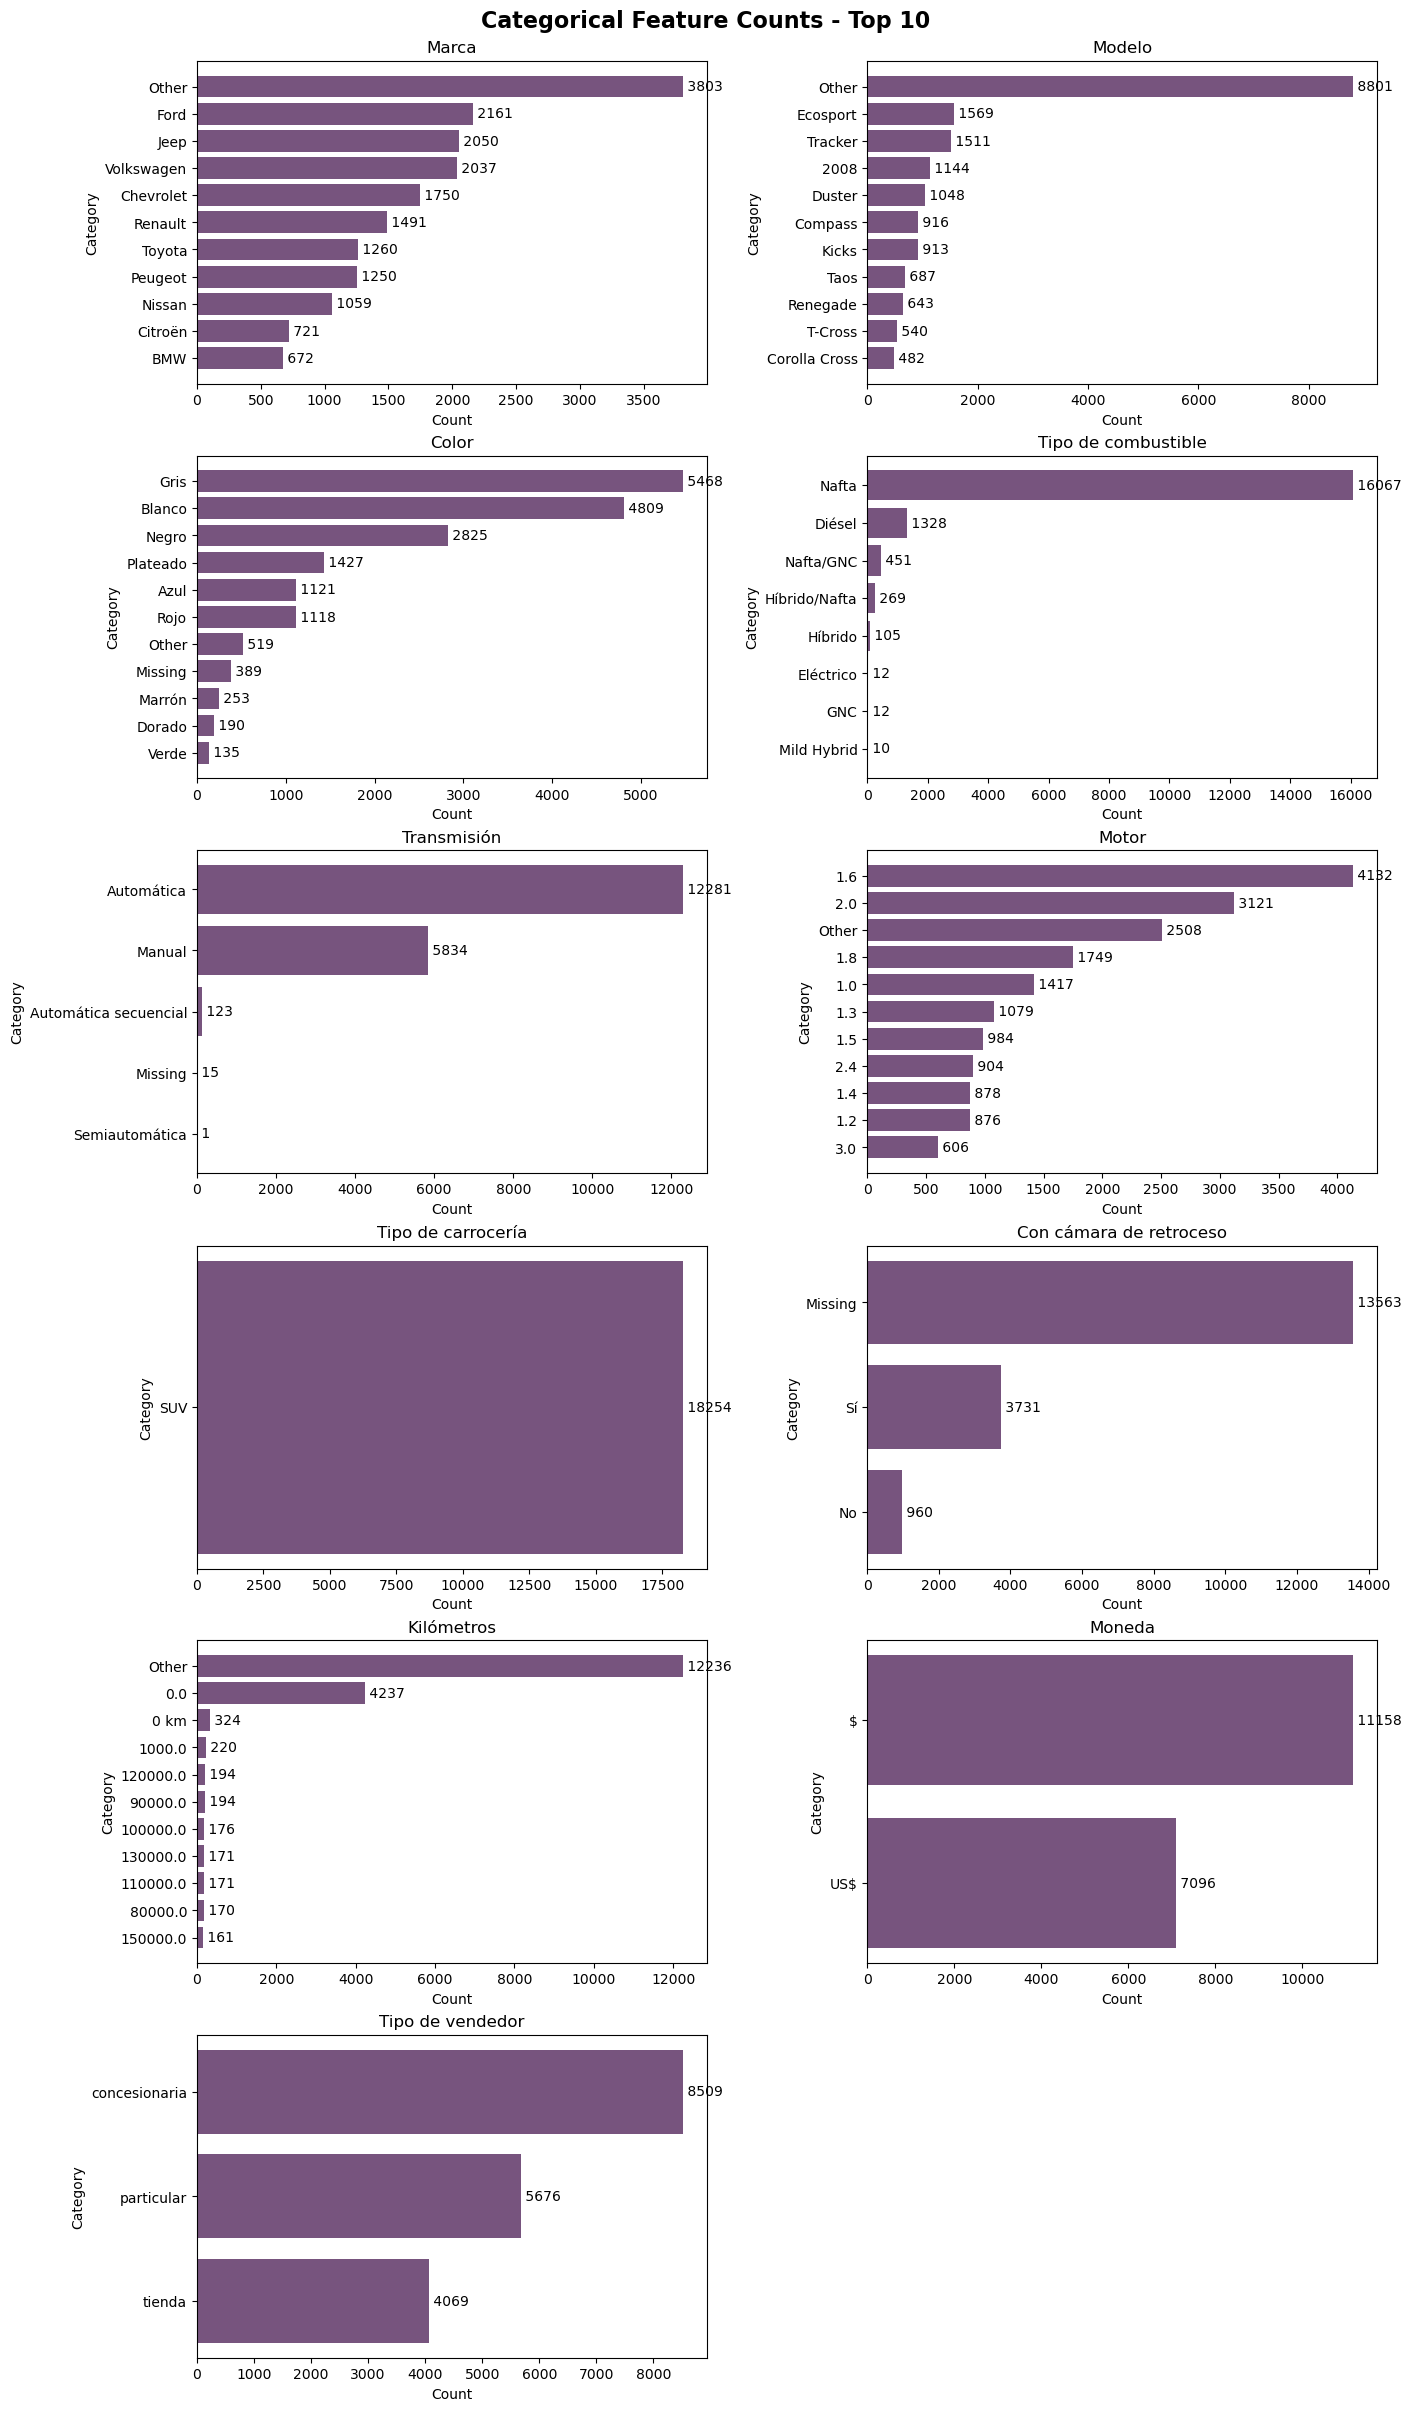

In [159]:
visual.plot_currency_counts(dataset)
visual.plot_categorical_counts(X, ignored_columns = ["Título", "Descripción", "Versión"], top_n = 10, n_cols = 2)

#### Análisis gráfico 1
Se observa que una mayor cantidad de publicaciones se encuentran expresadas en pesos que en dólares. Dado que el precio objetivo está representado en ambas monedas, resulta necesario unificar la unidad monetaria antes del modelado para evitar diferencias artificiales de escala.

#### Análisis gráfico 2
Los gráficos muestran que las variables categóricas no se distribuyen de la misma manera. Algunas están muy concentradas en pocas categorías, como `Tipo de combustible`, donde predominan los vehículos nafteros, y `Transmisión`, donde la mayoría de las publicaciones corresponden a cajas automáticas. También se observa que `Con cámara de retroceso` tiene una gran cantidad de valores faltantes, por lo que será necesario tratar esta variable con cuidado en el preprocesamiento.

Otras variables, como `Marca`, `Modelo`, `Motor`, `Color` y `Tipo de vendedor`, presentan más variedad de categorías. Aunque con este análisis no podemos asegurar que todas tengan relación con el target, sí parece razonable conservarlas y evaluarlas durante el modelado, ya que podrían reflejar diferencias entre tipos de vehículos, características del auto o formas de publicación.


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Numerical Variables and Target Distribution
</div>

Para mejorar la visualización de las distribuciones, se filtraron algunos valores fuera de rango o extremadamente altos. Sin este recorte, la escala de los gráficos quedaba dominada por pocos casos extremos y no permitía observar con claridad la forma general de las curvas.

Este comportamiento reafirma la existencia de posibles outliers, ya que unos pocos valores fueron suficientes para modificar notablemente la escala de las visualizaciones.

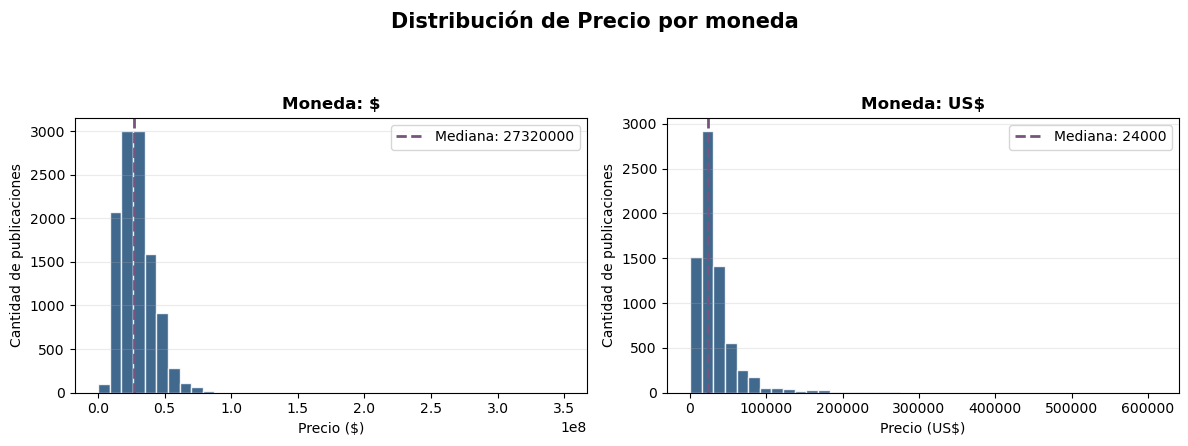

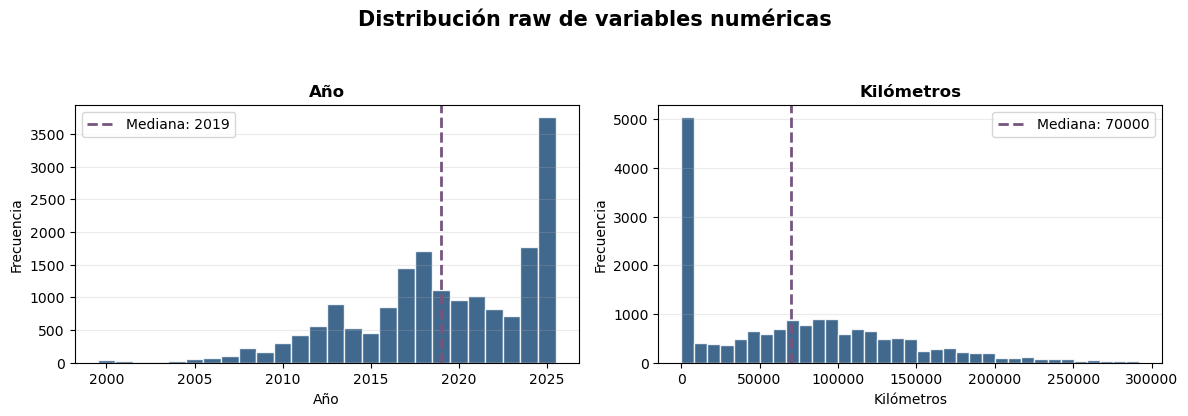

In [160]:
visual.plot_price_distribution_by_currency(dataset)
visual.plot_raw_numeric_distributions(dataset)

#### Análisis gráfico 1
Las distribuciones de `Precio` muestran una asimetría positiva en ambas monedas: la mayoría de las publicaciones se concentra en valores relativamente bajos, mientras que hay una cola hacia precios más altos. Esto indica que existen algunos vehículos bastante más caros que el resto.

Este patrón sugiere la presencia de posibles valores extremos y muestra que la variable objetivo no sigue una distribución normal. Por eso, será importante revisar más adelante que pasa cuando se le aplique logaritmo al `Precio`, intentando llevarla a una forma normal.

#### Análisis gráfico 2
La distribución de `Año` está concentrada en vehículos relativamente recientes. La mayoría de las publicaciones corresponde a modelos posteriores a 2015, con un pico marcado en los años más nuevos del dataset. Esto sugiere que la base está compuesta principalmente por SUVs modernas.

En el caso de `Kilómetros`, la distribución es asimétrica hacia la derecha: hay muchas publicaciones con bajo kilometraje y una cola que se extiende hacia valores más altos. También se observa una cantidad importante de vehículos con kilometraje nulo o cercano a cero, lo que probablemente corresponde a unidades nuevas o con muy poco uso.

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Preliminary Outlier Detection
</div>

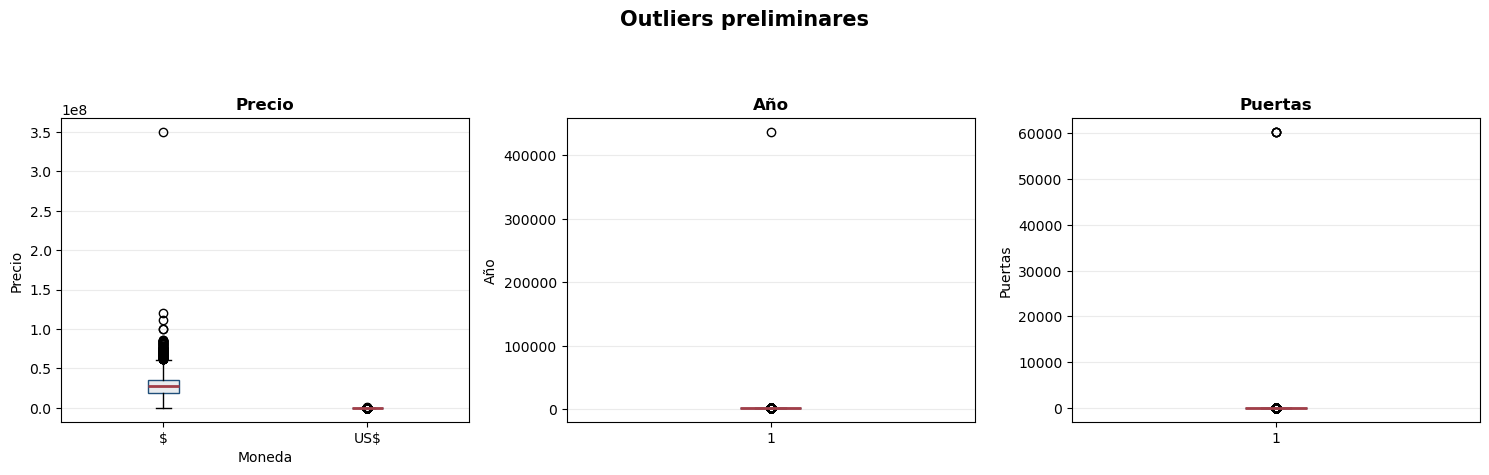

In [161]:
visual.plot_preliminary_outliers(dataset)

#### Análisis del gráfico
Los boxplots permiten identificar de forma preliminar la presencia de valores atípicos y posibles errores de carga en las variables numéricas. En `Precio` se observan algunos valores muy elevados en comparación con la mayor parte de las publicaciones, especialmente al analizar los precios separados por moneda.

Además, `Año` y `Puertas` presentan valores claramente imposibles para el contexto del problema, muy superiores a los rangos esperados, como habíamos anticipado en secciones anteriores

<h3
style="background-color: #343a40; color: #ffffff; 
display: inline-block; 
padding: 6px 10px;
border-radius: 6px;">
Initial Preprocessing
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Drop irrelevant columns
</div>

En primer lugar, se eliminan aquellas columnas que no aportan información útil para el entrenamiento de los modelos predictivos.

Por un lado, la columna **`Unnamed: 0`** corresponde al índice del dataset exportado a CSV y no contiene información descriptiva sobre los vehículos.

In [162]:
dataset_processed = prep.drop_irrelevant_columns(dataset.copy(), columns_to_drop=["Unnamed: 0"])

Por otro lado, se verifica si existen variables constantes, es decir, columnas cuyos valores son iguales para todas las observaciones. Este tipo de variables no aportan capacidad predictiva, ya que no permiten diferenciar entre ejemplos

In [163]:
eda.get_constant_columns(dataset_processed).style.hide(axis="index")

column,unique_value
Tipo de carrocería,SUV


Se observa que la única variable constante del conjunto de datos es **`Tipo de carrocería`**, cuyo valor es **"SUV"** para todas las publicaciones.

Dado que el dataset está compuesto exclusivamente por vehículos SUV, esta variable no aporta información discriminativa y, por lo tanto, se elimina del conjunto de datos.

In [164]:
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Tipo de carrocería"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Remove inconsistent values
</div>

Como se oservó anteriormente, las features `Año` y `Puertas` presentan valores sin sentido, por lo que se delimitó un rango de valores aceptables. Aquellos años superiores al 2025 (año de creación del dataset) fueron eliminados, al igual que los autos con más de cinco puertas. Por suerte, son tan solo diez muestras a eliminar

In [165]:
print("=== Chequeo de valores atípicos simples ===")
print(f"Año máximo: {dataset['Año'].max()}")
print(f"Cantidad de años mayores a 2025: {(dataset['Año'] > 2025).sum()}")
print()
print(f"Cantidad máxima de puertas: {dataset['Puertas'].max()}")
print(f"Cantidad de observaciones con más de 5 puertas: {(dataset['Puertas'] > 5).sum()}")

=== Chequeo de valores atípicos simples ===
Año máximo: 436694.0
Cantidad de años mayores a 2025: 1

Cantidad máxima de puertas: 60252.0
Cantidad de observaciones con más de 5 puertas: 9


In [166]:
range_rules = {"Año": {"max": 2025},"Puertas": {"max": 5},}
dataset_processed = prep.remove_invalid_values(dataset_processed, range_rules)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Convert prices to USD
</div>

Para entrenar un modelo predictivo consistente, todos los precios deben estar expresados en una misma moneda. Dado que el dataset contiene publicaciones en pesos argentinos y en dólares estadounidenses, se convierten los precios publicados en pesos a USD.

El dataset fue construido entre el 13/05/2025 y el 30/05/2025. Por este motivo, se utiliza como tipo de cambio el promedio de la cotización diaria del dólar oficial vendedor del Banco Nación durante ese período.

Fuente: [Cotización diaria del Dólar Banco Nación (BNA) - Mayo 2025](https://dolarhistorico.com/dolar-banco-nacion/mes/mayo-2025)

In [167]:
official_usd_sell = {
    "2025-05-13": 1150.00,
    "2025-05-14": 1150.00,
    "2025-05-15": 1150.00,
    "2025-05-16": 1160.00,
    "2025-05-19": 1155.00,
    "2025-05-20": 1160.00,
    "2025-05-21": 1160.00,
    "2025-05-22": 1155.00,
    "2025-05-23": 1150.00,
    "2025-05-26": 1160.00,
    "2025-05-27": 1170.00,
    "2025-05-28": 1175.00,
    "2025-05-29": 1195.00,
    "2025-05-30": 1195.00,
}

In [168]:
EXCHANGE_RATE = sum(official_usd_sell.values()) / len(official_usd_sell)
print(f"El tipo de cambio utilizado es de ${EXCHANGE_RATE:.2f}")

El tipo de cambio utilizado es de $1163.21


In [169]:
dataset_processed = prep.convert_peso_prices_to_usd(dataset_processed, EXCHANGE_RATE)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Kilometers to int
</div>

Como se observó, la columna **`Kilómetros`** fue cargada como *string*, por lo que hay que convertirla a float, teniendo en cuenta que algunos valores incluyen la unidad "km", la cual será eliminada.

In [170]:
dataset_processed["Kilómetros"] = (dataset_processed["Kilómetros"].apply(prep.extract_first_integer))

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Semantic Cleaning of Categorical Features
</div>

En esta etapa se aplican los reemplazos necesarios para estandarizar las variables categóricas identificadas previamente. Para ello, primero cada valor se normaliza mediante `normalize_category_text`, que transforma el texto a minúsculas, elimina tildes y homogeniza separadores y espacios. Luego, `apply_semantic_mapping` reemplaza cada variante por una categoría final definida manualmente mediante diccionarios de mapeo.

Los mapas de reemplazo se construyeron únicamente para aquellos casos en los que la equivalencia semántica era clara, evitando agrupar categorías que, aunque similares en su escritura, representan conceptos diferentes.

Además, los valores faltantes se mantienen como la categoría explícita `missing`. De esta manera, la ausencia de información se conserva como una señal potencialmente informativa para el modelo, en lugar de perderse durante las etapas posteriores de codificación

Para construir los mapeos semánticos se realizó una revisión manual de las categorías detectadas en el dataset. El objetivo fue unificar distintas escrituras de un mismo valor, corregir errores tipográficos evidentes y agrupar categorías que representaban conceptos muy similares. Por ejemplo, se unificaron marcas escritas con errores (`Jetour` y `Jetur`), variantes de modelos equivalentes o muy cercanas, y colores expresados con distintos nombres comerciales o tonalidades similares.

El criterio utilizado fue exploratorio y conservador: solo se agruparon valores cuando la equivalencia era clara o cuando la diferencia entre categorías no parecía aportar información relevante para el modelo. De esta forma, se buscó reducir la cardinalidad y evitar que pequeñas variaciones de escritura fragmenten artificialmente las variables categóricas.

In [171]:
BRAND_MAP = { #TODO: VER OTROSSSSSS DESP DE SPLIT
    "renault": ["renault", "rrenault"],
    "hyundai": ["hiunday", "hyundai"],
    "volkswagen": ["volkswagen", "vol"],
    "ds": ["ds", "d.s.", "d·s", "ds automobiles"],
    "land rover": ["range rover", "land rover"],
    "great wall motor": ["gwm", "haval"],
    "jetour": ["jetour", "jetur"],
}

MODEL_MAP = {
    "sw4": ["sw4", "hilux sw4"],
    "ds7": ["ds7", "ds7 crossback"],
    "clase ml": ["clase ml", "ml"],
    "santa fe": ["santa fe", "grand santa fe", "grand santa fé"],
    "tiggo 4": ["tiggo 4", "tiggo 4 pro"],
}

COLOR_MAP = {
    "blanco": ["blanca", "blanco", "blanco glaciar", "summit white", "mineralweiss metallic", "blanco nacre tricapa", "blanco banquise"],
    "negro": ["negra", "negro", "carbon black", "black meet kettle", "noir perla nera"],
    "amarillo": ["amarilla", "amarillo", "amarrillo"],
    "dorado": ["dorada", "dorado", "champaing"],
    "gris": ["gris", "gris plata", "gris platino", "plata", "plateado", "gray", "gris laque", "plata bari", "prata bari+tet vulc", "gris estrella", "gris artense"],
    "gris oscuro": ["gris oscuro", "gris selenium", "grafito", "granite crystal bc", "granite crysta bc", "gris titane", "gris indy", "gris silverstone", "skyscraper grau metallic"],
    "marron": ["marron claro", "marron oscuro", "cafe", "marron kodiak"],
    "azul": ["azul", "steel blue", "blue"],
    "rojo": ["rojo", "rojo sunset metalizado"],
    "verde": ["verde", "verde oscuro"],
    "beige": ["beige", "beige techo negro"],
    "celeste": ["celeste", "azul claro"],
    "naranja": ["naranja", "cobre"],
    "violeta": ["violeta", "morado", "morado oscuro"],
    "bordo": ["bordo"],
    "otros": ["otro", "acero", "rosa", "moundaz", "cendre", "blanco banchisa bicolor negro"]
}

FUEL_TYPE_MAP = {
    "hibrido": ["hibrido", "hibrido/nafta"]
}

TRANSMISSION_MAP = {
    "automatica": ["automática", "automatica", "automatica secuencial", "automática secuencial", "semiautomatica", "semiautomática"]
}


In [172]:
dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Marca", category_map = BRAND_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Modelo", category_map = MODEL_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Color", category_map = COLOR_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Tipo de combustible", category_map = FUEL_TYPE_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Transmisión", category_map = TRANSMISSION_MAP)

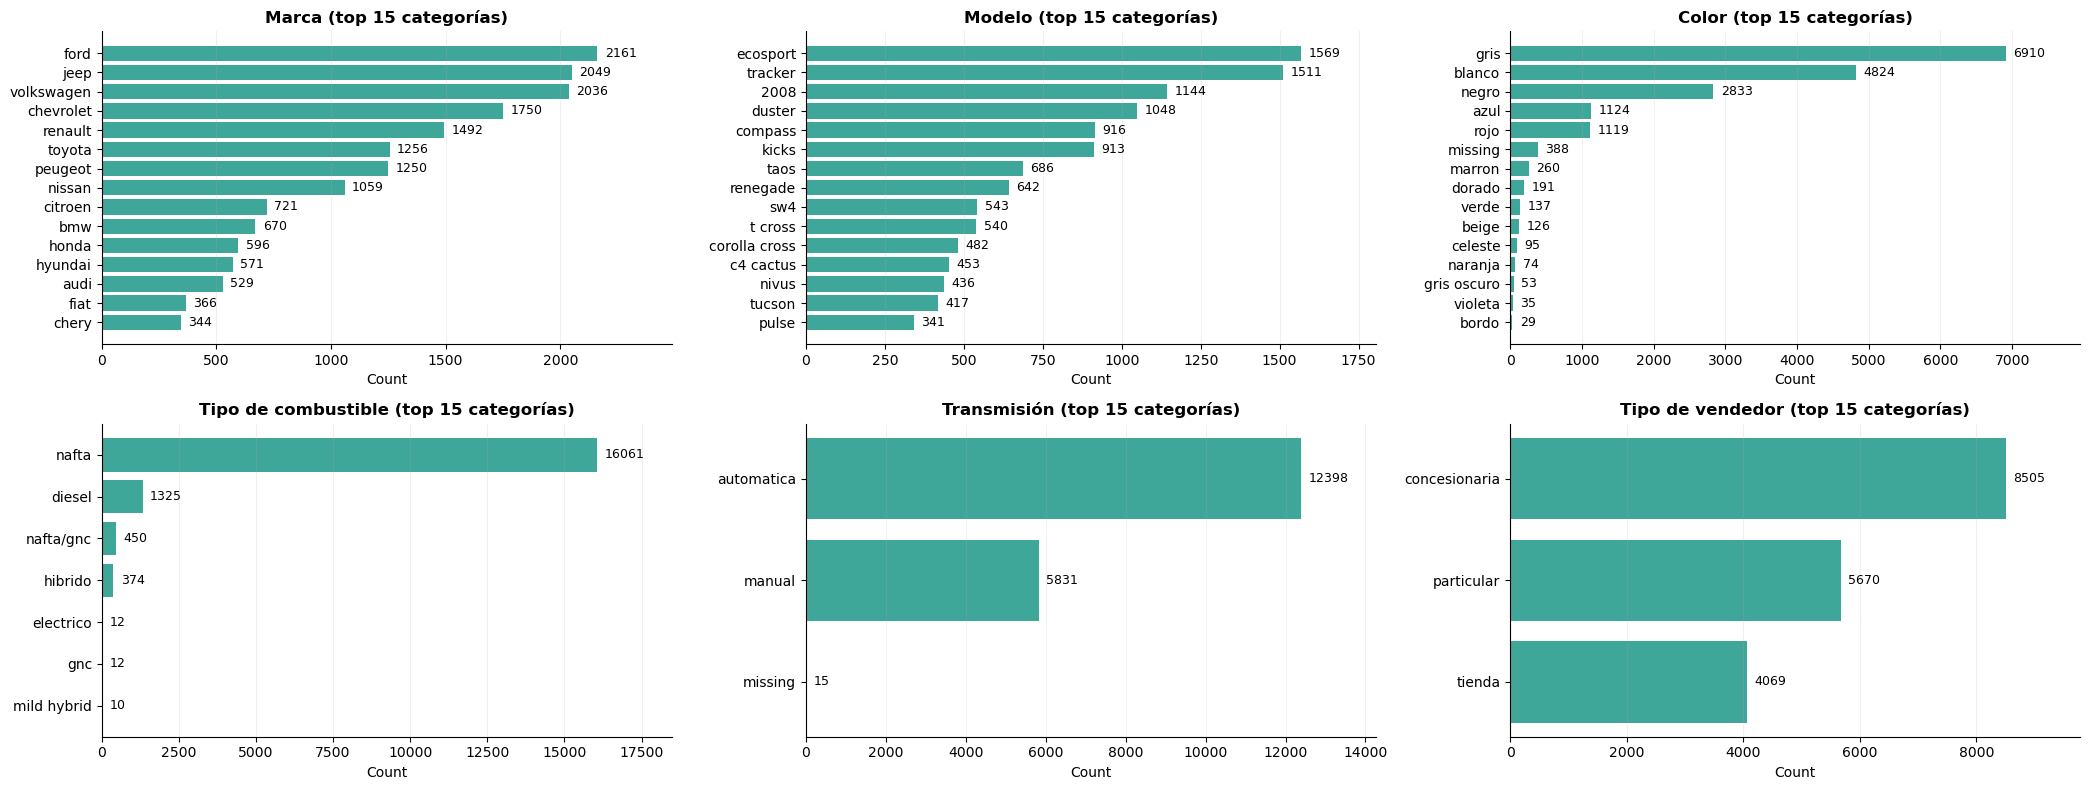

In [173]:
visual.plot_compact_value_counts(
    dataset_processed,
    columns=categorical_columns,
    top_n=15,
    n_cols=3
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Encode binary features
</div>

Dentro del conjunto de variables categóricas, la única que representa información binaria de tipo **sí/no** es `Con cámara de retroceso`. Para que pueda ser utilizada por los modelos predictivos, esta variable se transforma a una representación numérica:

- **1** si el vehículo tiene cámara de retroceso
- **0** si el vehículo no tiene cámara de retroceso

In [174]:
camera_map = {
    "sí": 1,
    "si": 1,
    "no": 0,
}

dataset_processed = prep.map_column_values(dataset_processed, column = "Con cámara de retroceso", value_map = camera_map)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Missing Value Handling
</div>

En esta sección se revisan algunos valores faltantes que pueden recuperarse a partir de información textual disponible en otras columnas del dataset, principalmente `Título`, `Descripción` y `Versión`.

No se imputan todos los valores faltantes, sino únicamente aquellos casos en los que el texto contiene una señal explícita y suficientemente clara. Para variables categóricas, como `Color` y `Transmisión`, primero se buscan menciones de categorías conocidas luego de aplicar la misma normalización semántica usada en la limpieza previa. Si se detecta una única categoría, el valor se completa; si aparecen varias categorías posibles, el caso se mantiene sin imputar para evitar asignaciones ambiguas.

Para variables con una estructura más específica, como `Motor` o `Con cámara de retroceso`, se usan extractores diseñados para detectar patrones concretos dentro del texto. En `Motor`, se buscan valores de cilindrada y señales de turbo. En `Con cámara de retroceso`, solo se completa el valor cuando aparece una mención explícita de la cámara.

Este criterio permite recuperar información que ya estaba presente en la publicación sin introducir imputaciones estadísticas todavía. Los valores que no puedan recuperarse con suficiente confianza se mantienen como faltantes o como categoría `missing`, y se revisan más adelante según su relevancia para el modelado.

### Color
Se buscan menciones de colores en las columnas de texto y se completan únicamente los casos con una sola categoría detectada.

In [175]:
color_row_mentions = eda.count_category_mentions_in_text(dataset_processed, target_col="Color", text_cols=("Título", "Descripción", "Versión"),
                                    category_map=COLOR_MAP, only_missing_target=True, only_rows_with_mentions=True,)
color_row_mentions.style.hide(axis = "index")

row_index,Color_is_missing,matched_categories,n_category_mentions
4407,True,azul,1
4476,True,blanco | negro,2
6776,True,gris,1
8804,True,beige,1
10789,True,blanco | negro,2
10884,True,azul,1
11095,True,blanco | gris | gris oscuro | negro,4
11460,True,blanco | negro,2
13138,True,negro,1
13220,True,gris | negro,4


In [176]:
dataset_processed, color_fill_audit = prep.fill_missing_from_single_text_match(dataset_processed, target_col="Color", matches_df = color_row_mentions,)
color_fill_audit.style.hide(axis = "index")

Missing rows in 'Color': 388
Filled from text matches: 8
Still missing after text matches search: 380


row_index,matched_categories,n_unique_matches,fill_value,target_col
4407,azul,1.000000,azul,Color
6776,gris,1.000000,gris,Color
8804,beige,1.000000,beige,Color
10884,azul,1.000000,azul,Color
13138,negro,1.000000,negro,Color
14804,blanco,1.000000,blanco,Color
15343,gris,1.000000,gris,Color
16483,blanco,1.000000,blanco,Color


### Motor
Se extrae información de cilindrada desde el texto y se conserva la señal de turbo cuando aparece explícitamente.

In [177]:
ENGINE_TEXT_MAP = {
    "1.0": [
        "1.0",
        "1.0t",
        "1.0 t",
        "1.0 tsi",
        "1.0 200 tsi",
    ],
    "1.3": [
        "1.3",
        "1.3 tce",
        "1.3 tce turbo",
        "1.3 t270",
    ],
    "1.5": [
        "1.5",
        "1.5t",
        "1.5 t",
        "1.5 turbo",
    ],
    "1.6": [
        "1.6",
        "1.6l",
        "1.6 16v",
        "1.6 vti",
        "1.6 thp",
    ],
    "1.8": [
        "1.8",
    ],
    "2.0": [
        "2.0",
        "2.0 sport",
        "2.0 sel",
        "2.0 hse",
        "2.0 turbo",
        "2.0 turbonaftero",
    ],
    "2.5": [
        "2.5",
    ],
    "2.8": [
        "2.8",
    ],
}

In [178]:
engine_row_mentions = eda.count_category_mentions_in_text(dataset_processed, target_col="Motor", text_cols=("Título", "Descripción", "Versión"), 
                                                          category_map=ENGINE_TEXT_MAP, only_missing_target=True, only_rows_with_mentions=True,)

engine_row_mentions.style.hide(axis = "index")

row_index,Motor_is_missing,matched_categories,n_category_mentions
209,True,2.5,2
219,True,1.0,4
2488,True,1.6,2
2764,True,1.8,3
3624,True,1.5,6
3760,True,1.6,4
4418,True,1.6,4
6095,True,1.5,3
7915,True,1.5,2
8264,True,1.0,2


In [179]:
dataset_processed, engine_audit = prep.fill_missing_from_text(dataset_processed, target_col="Motor", text_cols=("Versión", "Título", "Descripción"), 
                                                              extractor=prep.extract_engine_liters_from_text, extracted_col_name="extracted_engine",)

engine_audit.head(10).style.hide(axis = "index")

Missing rows in 'Motor': 38
Filled from text: 21
Still missing after text search: 17


row_index,text_used,extracted_engine,was_missing,was_filled
209,4X2 Hibrida AT Ford Kuga 2.5 Hibrida 4x2 At 2020 Ford Kuga 2.5 Hibrida 4X2 At 2020 con 45000 km. Oportunidad!!Unidad en optimas condicionesEntrega inmediataPrecio publicado de contadoFinanciacion Bancaria con DNITomamos permutasTodos los papeles listos para transferirManna Motors - Barracas (CABA),2.5,True,True
219,"1.0 200 Tsi Highline Tip Volkswagen T-Cross 1.0 200 Tsi Highline Tip Descubrí nuestro impresionante Volkswagen T-Cross del año 2025 en color Rojo !Este SUV de confianza te brinda una combinación perfecta de estilo, rendimiento y versatilidad. Con solo 0 km, este vehículo está listo para superar cualquier desafío que se le presente.En nuestra agencia, nos enorgullece ofrecer una amplia gama de vehículos multimarca, y el Volkswagen T-Cross es una de nuestras opciones destacadas. Nuestro equipo de expertos estará encantado de brindarte toda la información que necesites sobre este modelo y ayudarte a encontrar el vehículo perfecto que se ajuste a tus necesidades y preferencias.Este Volkswagen T-Cross se encuentra en excelente estado y está listo para rodar y transferir.Ofrece un gran valor por su precio su robustez y durabilidad son características emblemáticas de la marca, asegurándose una inversión a largo plazo.No pierdas esta oportunidad de tener el vehículo perfecto para tus necesidades¡Ven a visitarnos y descubre todo lo que esté Volkswagen T-Cross 2025 tiene para ofrecerte!Tomamos autos en parte de pago como permuta y en consignación para asegurarnos que tu proxima compra sea mas facil y placentera.",1.0 turbo,True,True
2488,"1.6 S 110cv 4x2 Ford Ecosport 1.6 S 110cv 4x2 Descubre nuestro impresionante Ford Eco Sport del año 2017, en color Blanco.Este Ford es confiable, brinda una combinación perfecta de estilo, rendimiento y versatilidad. Con solo 115000 km, este vehículo está listo para superar cualquier desafío que se le presente.En nuestra agencia, nos enorgullece ofrecer una amplia gama de vehículos multimarca, y el Ford Eco Sport es una de nuestras opciones destacadas. Nuestro equipo de expertos estará encantado de brindarte toda la información que necesites sobre este modelo y ayudarte a encontrar el vehículo perfecto que se ajuste a tus necesidades y preferencias.Este Ford Eco Sport se encuentra en excelente estado y está listo para rodar y transferir. Ofrece un gran valor por su precio, y su robustez y durabilidad son características emblemáticas de la marca, asegurando una inversión a largo plazo.No pierdas esta oportunidad de tener el vehículo perfecto para tus necesidades. Ven a visitarnos y descubre todo lo que el Ford Eco Sport 2017 tiene para ofrecerte.Ofrecemos opciones de toma en parte de pago como permuta y consignación para asegurarnos de que tu próxima compra sea más fácil y placentera.",1.6,True,True
2764,"1.8 4x2 Sport Jeep Renegade 1.8 4x2 Sport Somos ExpoUsados de San Luis Jeep Renegade 1.8 4X2 Sport 2018 con 62297 km. Estamos a su disposición para despejar cualquier consulta o mostrarle toda nuestra variedad de vehículos multimarca en stock. Ofrecemos amplias posibilidades de financiación y toma de usado (sujeto a año, km y peritaje) ¡Su consulta no es molestia! ¡Lo esperamos!Nuestros horarios de atención son de lunes a viernes de 9 hs a 18 hs y sabados de 9 hs a 13 hs.",1.8,True,True
3624,"1.5 Turbo LX 4x2 Honda Cr-v 1.5 Turbo Lx 4x2 Honda CRV LX 4X2 1.5 turbo 191cv, Blanco perlado, entrega inmdata",1.5 turbo,True,True
3760,"1.6 Thp 165 At6 Shine Citroën C4 Cactus 1.6 Thp 165 At6 Shine Descubrí nuestro impresionante Citroen C 4 Cactus del año 2025 en color Rojo !Este SUV de confianza te brinda una combinación perfecta de estilo, rendimiento y versatilidad. Con solo 0 km, este vehículo está listo para superar cualquier desafío que se le presente.En nuestra agencia, nos enorgullece ofrecer una amplia gama de vehículos multimarca, y el Citroen C 4 Cactus es una de nuestras opciones destacadas. Nuestro equipo de expertos estará 

### Transmisión
Se buscan variantes textuales de transmisión manual o automática y se imputan solo los casos no ambiguos.

In [180]:
TRANSMISSION_MAP_TEXT = {
    "automatica": [
        "automatica",
        "automatico",
        "caja automatica",
        "at",
        "at6",
        "at8",
        "at9",
        "cvt",
        "dsg",
        "tiptronic",
        "secuencial",
    ],
    "manual": [
        "manual",
        "caja manual",
        "mt",
    ],
}

In [181]:
transmission_row_mentions = eda.count_category_mentions_in_text(dataset_processed, target_col="Transmisión", text_cols=("Título", "Descripción", "Versión"), category_map=TRANSMISSION_MAP_TEXT, 
                                                                only_missing_target=True, only_rows_with_mentions=True,)

transmission_row_mentions.style.hide(axis = "index")

row_index,Transmisión_is_missing,matched_categories,n_category_mentions
2194,True,automatica,2
5507,True,automatica,2
7663,True,automatica,4
12920,True,automatica,2
12979,True,automatica,2
17594,True,automatica,4
17665,True,automatica | manual,8


In [182]:
dataset_processed, transmission_fill_audit = prep.fill_missing_from_single_text_match( dataset_processed, target_col="Transmisión", matches_df=transmission_row_mentions,)
transmission_fill_audit.style.hide(axis = "index")

Missing rows in 'Transmisión': 15
Filled from text matches: 6
Still missing after text matches search: 9


row_index,matched_categories,n_unique_matches,fill_value,target_col
2194,automatica,1.000000,automatica,Transmisión
5507,automatica,1.000000,automatica,Transmisión
7663,automatica,1.000000,automatica,Transmisión
12920,automatica,1.000000,automatica,Transmisión
12979,automatica,1.000000,automatica,Transmisión
17594,automatica,1.000000,automatica,Transmisión


### Con cámara de retroceso

Se completa la variable únicamente cuando el texto menciona explícitamente la presencia de cámara de retroceso.

In [183]:
CAMARA_MAP = {
    "Camara de retroceso": ["Cámara de retroceso", "Camara de retroceso"]
}

In [184]:
camera_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Con cámara de retroceso",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=CAMARA_MAP,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

camera_row_mentions.head(30)

,row_index,Con cámara de retroceso_is_missing,matched_categories,n_category_mentions
0,4,True,camara de retroceso,1
1,45,True,camara de retroceso,1
2,54,True,camara de retroceso,1
3,175,True,camara de retroceso,1
4,269,True,camara de retroceso,1
5,276,True,camara de retroceso,1
6,292,True,camara de retroceso,1
7,435,True,camara de retroceso,1
8,446,True,camara de retroceso,1
9,541,True,camara de retroceso,1


In [185]:
dataset_processed, camera_audit = prep.fill_missing_from_text( dataset_processed, target_col="Con cámara de retroceso", text_cols=("Título", "Descripción", "Versión"), 
                                                              extractor=prep.extract_backup_camera, extracted_col_name="extracted_camera",)

camera_audit.head(10).style.hide(axis = "index")

Missing rows in 'Con cámara de retroceso': 13556
Filled from text: 486
Still missing after text search: 13070


row_index,text_used,extracted_camera,was_missing,was_filled
4,"Jeep Compass 2.4 Sport At •Unico dueño•Todos los services oficiales•Bateria nueva•2 juegos de alfombras•Caja Automatica•Motor 2.4 Nafta•Climatizador Bi zona•Arranque Star Stop•Cámara de retroceso•Faros Led•Chapon cubre carter•2 gomas nuevas•Tuercas de seguridad•107500 km (aprox al 1/4/25)EXCELENTE ESTADONo FinancioNo PermutoSe puede ver x canning o sarandí, avellaneda. 2.4 Sport At",1.000000,True,True
36,"Mercedes-Benz Clase GLE GLE 450 4MATIC (MHEV) Desde AutoPremium Usados Seleccionados tenemos para ofrecerte una MERCEDES BENZ GLE 450 4MATIC (MHEV) 2023 con 15000Kms.Cuenta con toda la documentación al día, listo para transferir.El precio publicado es en dolar informal TC venta.Características destacadas:- CAJA AUTOMATICA- VOLANTE MULTIFUNCIÓN- TAPIZADO DE CUERO Y ALCANTARA- ASIENTOS DELANTEROS REGULABLES ELECTRICAMENTE, CON MEMORIAS- ASIENTOS CALEFACTADOS PARA CONDUCTOR Y ACOMPAÑANTE- DIFERENTES MODOS DE MANEJO- LIMPIAPARABRISAS CON SENSOR DE LLUVIA- PAQUETE DE ESTACIONAMIENTO CON CAMARA DE MARCHA ATRAS- PORTON TRASERO CON ACCIONAMIENTO ELECTRICO- SISTEMA DE SONIDO ADVANCED- SISTEMA INALÁMBRICO DE CARGA PARA CELULARES- ASISTENTE ACTIVO DE DISTANCIA DISTRONIC- CONTROL DE ANGULO MUERTO Y DETECTOR DE CAMBIO DE CARRIL- FUNCION HOLD- ATTENTION ASSIST (MONITOREO DE CANSANCIO DEL CONDUCTOR)- LLANTAS DE ALEACION- FAROS DE LED- NAVEGADOR- SENSORES DE ESTACIONAMIENTO- CLIMATIZADOR AUTOMATICO BI-ZONA- USB- BLUETOOTH GLE 450 4MATIC (MHEV)",1.000000,True,True
45,"Kia Sorento 2.5 Ex Crdi 170 Hp At Kia sorento motor 2.5 de 170 hp estéreo sistema Android, bluetooth, gps,cámara de retroceso, asientos de cuero muy buena Soy dueño,pero aclaro que el motor no funciona, tiene el motor echo a nuevo pero no funciona 2.5 Ex Crdi 170 Hp At",1.000000,True,True
54,Toyota RAV4 2.5 4x4 6at TOYOTA RAV4 VX 2.5l 4x4 AT - modelo 2013- segundo dueño 136.000km- motor 2.5l (cadenero)- tracción 4x4 permanente - modo de conducción eco y SPORT - tapizado de cuero- techo corredizo - butaca del conductor con regulación eléctrica- butacas delanteras calefaccionadas - cámara de retroceso - frenos abs - control de estabilidad - espejos rebatibles automáticamente - climatizador automático- faros antinieblas delanteros y traseros - ESTADO : INMACULADO ! Única en su estado - Precio :USD 25.800 dólares !!- Precio: permuta USD 27.800 dólares 2.5 4x4 6at,1.000000,True,True
86,"BMW X3 2.0 Xdrive 30E Xline Descripción!!!!Desde AutoPremium Usados Seleccionados tenemos para ofrecerte un BMW X3 XDRIVE 30E 2023 Con 16000 KmsPosee todos los servicios oficiales realizados. Cuenta con toda la documentación al día, listo para transferir.El precio publicado es en dolar informal TC venta.Características destacadas:- CAJA AUTOMATICA- TABLERO DIGITAL- VOLANTE MULTIFUNCION- SISTEMA DE ASISTENCIA A LA CONDUCCION- ASIENTOS TAPIZADOS EN CUERO Y TELA- ASIENTOS DELANTEROS CON REGULACION ELECTRICA- DIFERENTES MODOS DE MANEJO- AUTO HOLD- LLANTAS DE ALEACION- FAROS DE LED- NAVEGADOR- CARPLAY- TECHO PANORAMICO CORREDIZO ELECTRICO- SENSORES DE ESTACIONAMIENTO DELANTEROS Y TRASEROS- CAMARA TRASERA DE ESTACIONAMIENTO- CLIMATIZADOR AUTOMATICO BI-ZONA- USB- BLUETOOTH 2.0 Xdrive 30E Xline",1.000000,True,True
155,"Audi Q3 1.4 Tfsi Stronic 150 Cv Audi Q3 35 TFSI35 TFSI corresponde a motor 1.4 TFSI de 150CV- Audi drive select- Audi soundsystem- Techo corredizo panorámico- Asientos tapizados en Leatherette- Confort Key(acceso y arranque sin llave)- Climatizador automático confort de 2 zonas- Portón del maletero de apertura y cierre eléctricos- Control de velocidad crucero con limitador de velocidad- Cuadro de instrumentos Digital ClusterDisplayde 10,2”- Audi smartphoneinterface compatible con Android Auto y Apple CarPlay- Llantas de aluminio fundido de 5 brazos dobles con neumáticos 235/55 R18- Asientos traseros con reglaje horizontal, reposabrazos central y porta bebidas- Volante de cuero en diseño de 3 radios con multifunción plus y levas de c

# REVISAR

In [186]:
# dataset_processed, camera_imputation_audit = prep.impute_backup_camera_by_brand_model_year(
#     dataset_processed)

# ----

Ahora bien, aquellos faltantes que corresponden a autos fabricados antes del año 2000 
podemos asumirlos como 0, ya que la cámara de retroceso no era una tecnología 
disponible en esa época.

In [187]:
dataset_processed = prep.impute_missing_by_year(dataset_processed, "Con cámara de retroceso", year_threshold = 2000)

Filled 131 rows in 'Con cámara de retroceso' with 0 (older than 2000)


KNN: si el KNN usa información de features para imputar, lo ideal metodológicamente es ajustarlo solo con train y aplicarlo luego a test, para evitar leakage.

In [188]:
# dataset_processed, camera_knn_audit = knn.impute_missing_knn(
#     dataset_processed,
#     target_col="Con cámara de retroceso",
#     feature_cols=["Año", "Kilómetros", "Precio"],
#     n_neighbors=5,
#     round_result=True,
#     clip_range=(0, 1),
# )

### Checking updated dataset

In [189]:
# Previous missing values
eda.missing_values_summary(dataset).style.hide(axis = "index")

column,missing_count,missing_percentage
Con cámara de retroceso,13563,74.300000
Color,389,2.130000
Motor,38,0.210000
Transmisión,15,0.080000


In [190]:
# Current missing values
eda.missing_values_summary(dataset_processed).style.hide(axis = "index")

column,missing_count,missing_percentage
Con cámara de retroceso,12939,70.920000
Color,380,2.080000
Motor,17,0.090000
Transmisión,9,0.050000


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
New Columns to Represent Engine Feature
</div>

Para la variable `Motor`, se busca extraer información técnica que aparece escrita de distintas formas en el texto original. En particular, se recupera la cilindrada del motor y se conserva la presencia de turbo cuando esta información aparece explícitamente mencionada.

Ya se completaron algunos valores faltantes de `Motor` utilizando las columnas `Título`, `Descripción` y `Versión`. Para esto se identifican patrones confiables de cilindrada, como `1.6`, `2.0`, `1.5t`, `1.3 TCE`, `1.0 TSI` o valores en centímetros cúbicos como `1600 cc`. Cuando además se detectan expresiones asociadas a turbo, como `turbo`, `TSI`, `TDI`, `THP` o `TCE`, el valor imputado conservó esa información en el texto, por ejemplo `1.5 turbo`.

Luego, a partir de la columna `Motor` ya completada, se crean nuevas variables. La columna `Cilindrada` almacena la cilindrada extraída en litros como valor numérico, mientras que `Tiene turbo` indica si el motor presenta señales de turbo en el texto.

De esta forma, la información técnica contenida originalmente en `Motor` queda representada en columnas más limpias y comparables. Una vez creadas estas variables derivadas, la columna original `Motor` puede eliminarse del dataset final.

In [191]:
TURBO = [
    "turbo",
    "turboalimentado",
    "tsi",
    "tdi",
    "tfsi",
    "ecoboost",
    "tce",
    "thp",
    r"\bt\b", # Match 't' as a whole word
    r"\d\.\d\s*t\b", # Match patterns like '1.6 T'
]

In [192]:
dataset_processed["Cilindrada"] = dataset_processed["Motor"].apply(prep.extract_engine_liters)
dataset_processed["Cilindrada"].isna().sum()

np.int64(311)

Algunas columas de `Motor` solo decian cosas como "Turboalimentado", por lo que tienen NAN a la hora de completar la cilindrada. Esos valores los podemos recuperar de las columnas `Versión` y `Descripción`

In [193]:
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Versión"].apply(prep.extract_engine_liters)
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Descripción"].apply(prep.extract_engine_liters)

In [194]:
print(dataset_processed["Cilindrada"].isna().sum())
print(dataset_processed["Cilindrada"].head())

22
0    1.5
1    2.0
2    1.4
3    1.5
4    2.4
Name: Cilindrada, dtype: float64


In [195]:
dataset_processed["Tiene turbo"] = dataset_processed["Motor"].apply(lambda value: prep.has_turbo(value, turbo_patterns = TURBO))

In [196]:
# Deleting Motor column as it has been processed into new features
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Motor"])

In [197]:
dataset_processed["Tiene turbo"].value_counts()

Tiene turbo
0    17874
1      370
Name: count, dtype: int64

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Text-Based Condition Features
</div>

Las columnas `Título`, `Descripción` y `Versión` tienen bastante información escrita por los vendedores. Parte de esa información ya la usamos para completar valores faltantes, como `Color`, `Motor`, `Transmisión` o `Con cámara de retroceso`.

Antes de eliminar estas columnas, se busca rescatar algunas señales simples que pueden ser útiles para predecir el precio. En vez de aplicar un modelo de NLP más complejo, se define un conjunto de palabras y frases de interés y se crean variables binarias que indiquen si esas expresiones aparecen o no en la publicación.

In [198]:
eda.frequent_words_table(dataset_processed, text_cols=("Título", "Descripción", "Versión"), top_n=50).style.hide(axis = "index")

word,count
000,7497
4x2,6118
cvt,4754
usado,4502
jeep,4004
volkswagen,3913
estado,3893
tsi,3851
usados,3845
4x4,3840


Teniendo un paneo general de las palabras más frecuengtes, vemos hay gran variedad de tipos de palabra. Muchas de estas están relacionadas al auto como producto, pero no hablan mucho del estado. Por eso, podríamos buscar la frecuencia de palabras agrupadas según el tipo de información que representan. Por ejemplo, algunas expresiones hacen referencia a documentación o papeles al día, otras a services o mantenimiento, otras al buen estado del vehículo, y otras a posibles detalles o daños. Vamos a gregar columnas binarias que representen estas condiciones.

Tambien, agregaremos una columna para identificar las publicaciones en las que no aparece ninguna de estas señales. Esto permite diferenciar entre autos con alguna información textual relevante y publicaciones donde el texto no aporta demasiado en este sentido.

In [199]:
INTEREST_TERMS = {
    "papeles": [
        "papeles al dia",
        "documentacion al dia",
        "documentacion en regla",
        "listo para transferir",
        "lista para transferir",
        "sin deudas",
        "libre deuda",
        "libre de deuda",
        "vtv",
        "verificacion policial",
    ],
    "service": [
        "service",
        "services",
        "service oficial",
        "services oficiales",
        "mantenimiento",
        "distribucion hecha",
        "bateria nueva",
        "cubiertas nuevas",
    ],
    "buen_estado": [
        "buen estado",
        "muy buen estado",
        "excelente estado",
        "excelentes condiciones",
        "buenas condiciones",
    ],
    "impecable": [
        "impecable",
        "impecables",
        "sin detalles",
        "como nuevo",
        "como nueva",
        "como 0km",
    ],
    "cuidado": [
        "cuidado",
        "cuidada",
        "muy cuidado",
        "muy cuidada",
        "bien cuidado",
        "bien cuidada",
    ],
    "detalles_uso": [
        "detalles de uso",
        "detalle de uso",
        "detalles esteticos",
        "detalle estetico",
    ],
    "daño": [
        "rayado",
        "rayada",
        "rayones",
        "golpe",
        "golpes",
        "golpeado",
        "golpeada",
        "abollado",
        "abollada",
        "abolladura",
    ],
    "sin_choque": [
        "sin choque",
        "sin choques",
        "nunca chocado",
        "nunca chocada",
    ],
}

In [200]:
eda.count_interest_terms_in_text(dataset_processed, text_cols=("Título", "Descripción", "Versión"), terms_map=INTEREST_TERMS).style.hide(axis = "index")

term,count,row_count
papeles,3819,2842
service,3503,2611
buen_estado,2918,2299
impecable,1998,1748
cuidado,957,530
daño,69,65
detalles_uso,61,61
sin_choque,34,34


In [201]:
dataset_processed = prep.add_text_indicator_features(dataset_processed, text_cols=("Título", "Descripción", "Versión"), terms_map=INTEREST_TERMS, 
add_no_match_feature=True, no_match_feature_name="sin_condicion",)

In [202]:
dataset_processed.columns

Index(['Marca', 'Modelo', 'Año', 'Versión', 'Color', 'Tipo de combustible',
       'Puertas', 'Transmisión', 'Con cámara de retroceso', 'Kilómetros',
       'Título', 'Precio', 'Descripción', 'Tipo de vendedor', 'Cilindrada',
       'Tiene turbo', 'papeles', 'service', 'buen_estado', 'impecable',
       'cuidado', 'detalles_uso', 'daño', 'sin_choque', 'sin_condicion'],
      dtype='str')

Estas variables no dicen por sí solas si el precio debería subir o bajar. Por ejemplo, una mención a `service` o `impecable` podría estar asociada a un mejor estado del auto, mientras que una mención a `rayones` o `golpes` podría indicar lo contrario. La idea es dejar que el modelo aprenda esa relación a partir de los datos.

Una vez extraídas estas señales, las columnas originales de texto ya no se van a usar directamente, entonces las sacamos.

In [203]:
# dataset_processed = prep.drop_irrelevant_columns(dataset_processed,columns_to_drop=["Título", "Descripción", "Versión"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Final Missing Value Encoding
</div>

Antes de separar el dataset y aplicar one-hot encoding, se completan los valores faltantes restantes en las variables categóricas. En lugar de eliminar estas observaciones o imputarlas con una categoría mayoritaria, se reemplaza cada faltante por una categoría explícita asociada a su columna.

Por ejemplo, un valor faltante en `Color` se reemplaza por `missing_Color`, mientras que un faltante en `Transmisión` se reemplaza por `missing_Transmisión`. Esto permite conservar la información de que el dato no estaba disponible, y deja que el modelo aprenda si esa ausencia tiene alguna relación con el precio.

In [204]:
dataset_processed = prep.fill_missing_with_value(dataset_processed)                                                     

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Outliers Detection
</h3>

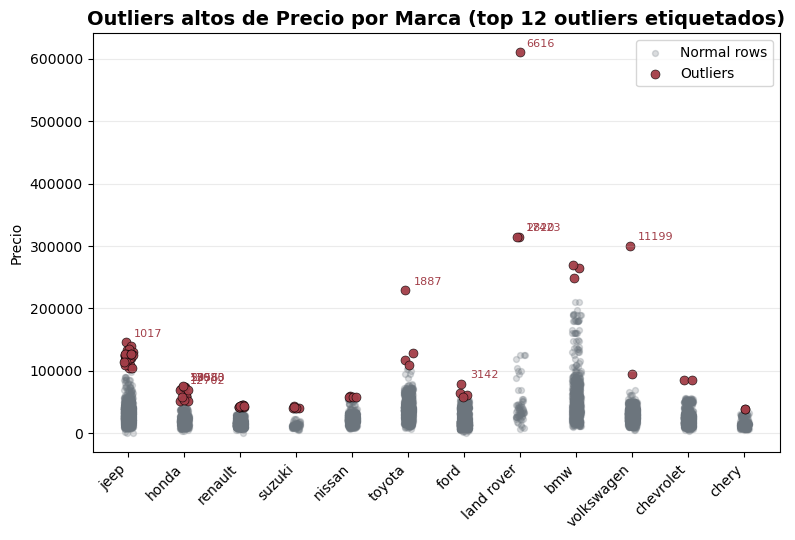

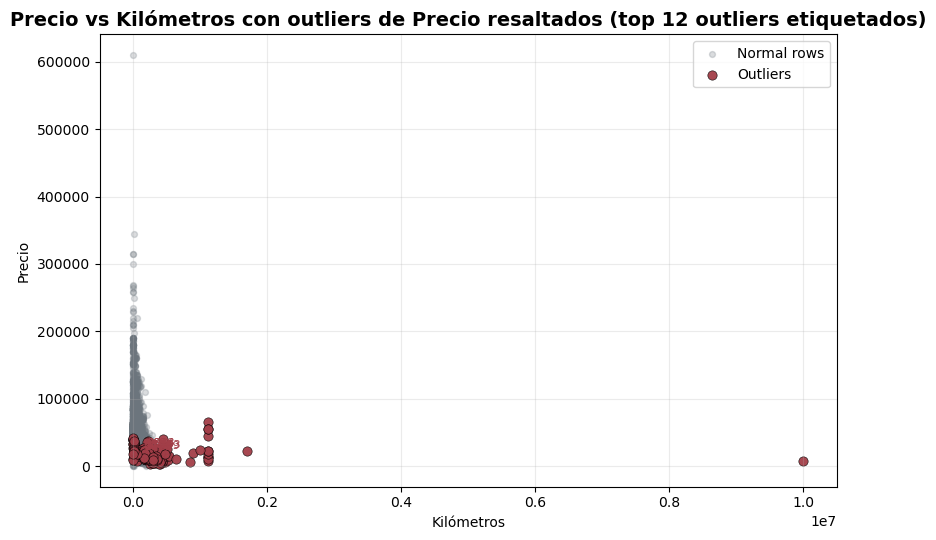

In [205]:
price_outliers = visual.plot_iqr_outliers(dataset_processed, value_col="Precio", group_col="Marca", context_cols="all",
                                          min_group_size=50, side="high", top_n_labels=12, title="Outliers altos de Precio por Marca", iqr_multiplier = 4.0)

price_km_outliers = visual.plot_iqr_outlier_scatter(dataset_processed, x_col="Kilómetros", y_col="Precio",outlier_col="Kilómetros",group_col="Marca", 
context_cols="all", min_group_size=50,side="high",title="Precio vs Kilómetros con outliers de Precio resaltados",)

Observamos que los outliers detectados con iqr no son del todo válidos. Autos 0km no deberían ser outliers, ni tampoco autos con precios de $USD 250.000 que refieren a marcas de alta gama. Por este motivo, utilizaremos un rango definido por nosotras para delimitar los valores de estos features.

In [206]:
rules = {
"Precio":{"method": "fixed", "min": 1000, "max": 400_000},
"Kilómetros":  {"method": "fixed", "min": 0,"max": 600_000},
}

# Inspect possible outliers
df_flagged = prep.detect_outliers(dataset_processed, rules, mode="flag")
df_flagged[df_flagged["is_outlier"]].drop(columns = ["Descripción"]).head(20).style.hide(axis = "index")

Total rows flagged as outliers (any column): 21 (0.12%)
    column method  allow_zero  lower_bound  upper_bound  outliers_found  outlier_%
    Precio  fixed       False         1000       400000               4       0.02
Kilómetros  fixed       False            0       600000              17       0.09


is_outlier,is_outlier_Precio,is_outlier_Kilómetros,Marca,Modelo,Año,Versión,Color,Tipo de combustible,Puertas,Transmisión,Con cámara de retroceso,Kilómetros,Título,Precio,Tipo de vendedor,Cilindrada,Tiene turbo,papeles,service,buen_estado,impecable,cuidado,detalles_uso,daño,sin_choque,sin_condicion
True,False,True,ford,explorer,1994.000000,4.0 Xlt 4x4 At,gris,nafta,5.000000,automatica,0.000000,850000,Ford Explorer 4.0 Xlt 4x4 At,5995.000000,particular,4.000000,0,1,0,0,0,0,0,0,0,0
True,False,True,ford,bronco,1981.000000,V8,marron,nafta,2.000000,manual,0.000000,1111111,Ford Bronco V8,65000.000000,concesionaria,8.000000,0,0,0,0,0,0,0,0,0,1
True,True,False,renault,duster,2025.000000,1.6 Hr16 Intens 115Cv,gris,nafta,5.000000,manual,nan,1000,Renault Duster 1.6 Hr16 Intens 115Cv,111.000000,concesionaria,1.600000,0,0,0,0,0,0,0,0,0,1
True,True,False,jeep,wrangler,2025.000000,2.0 Rubicon 272Hp Atx,gris,nafta,3.000000,automatica,nan,0,Jeep Wrangler 2.0 Rubicon 272Hp Atx,102.302733,concesionaria,2.000000,0,0,0,0,0,0,0,0,0,1
True,False,True,renault,duster,2013.000000,2.0 4x2 Luxe 138cv,negro,nafta,5.000000,manual,nan,1111111,Renault Duster 2.0 4x2 Luxe 138cv,13067.239791,concesionaria,2.000000,0,0,0,0,0,0,0,0,0,1
True,False,True,renault,duster,2018.000000,1.6 Ph2 4x2 Dynamique,negro,nafta/gnc,5.000000,manual,nan,1111111,Renault Duster 1.6 Ph2 4x2 Dynamique,14000.000000,particular,1.600000,0,0,0,0,0,0,0,0,0,1
True,False,True,renault,duster,2013.000000,1.6 4x2 Confort Plus 110cv,blanco,nafta,5.000000,manual,0.000000,1111111,Renault Duster 1.6 4x2 Confort Plus 110cv,7500.000000,concesionaria,1.600000,0,1,0,0,0,0,0,0,0,0
True,True,False,land rover,range rover sport,2024.000000,SV V8,negro,nafta,5.000000,automatica,1.000000,0,Range Rover Sport Sv,610000.000000,concesionaria,8.000000,0,0,0,0,0,0,0,0,0,1
True,False,True,ford,bronco,1981.000000,V8,negro,nafta,3.000000,automatica,0.000000,1111111,Ford Bronco V8,45000.000000,concesionaria,8.000000,0,0,0,0,0,0,0,0,0,1
True,False,True,chevrolet,blazer,2000.000000,2.8 Dlx 4x2,verde,diesel,5.000000,manual,nan,9999999,Chevrolet Blazer 2.8 Dlx 4x2,7995.087504,particular,2.800000,0,1,1,1,0,0,0,0,0,0


In [207]:
# Deleting outliers
dataset_processed = prep.detect_outliers(dataset_processed, rules, mode="drop")
print()
print(dataset_processed.shape)

Total rows flagged as outliers (any column): 21 (0.12%)
    column method  allow_zero  lower_bound  upper_bound  outliers_found  outlier_%
    Precio  fixed       False         1000       400000               4       0.02
Kilómetros  fixed       False            0       600000              17       0.09

(18223, 25)


Podríamos observar además, si hay algún outlier por marca. Son las marcas de alta gama las que tienen autos de mas de 100 mil dólares, por loq ue podríamos analizar si hay algun precio qu ehaga ruido

======================== Outliers por Marca ========================
Filtered out 8 categories with fewer than 10 rows.
Plotting 30 categories split into 3 charts.


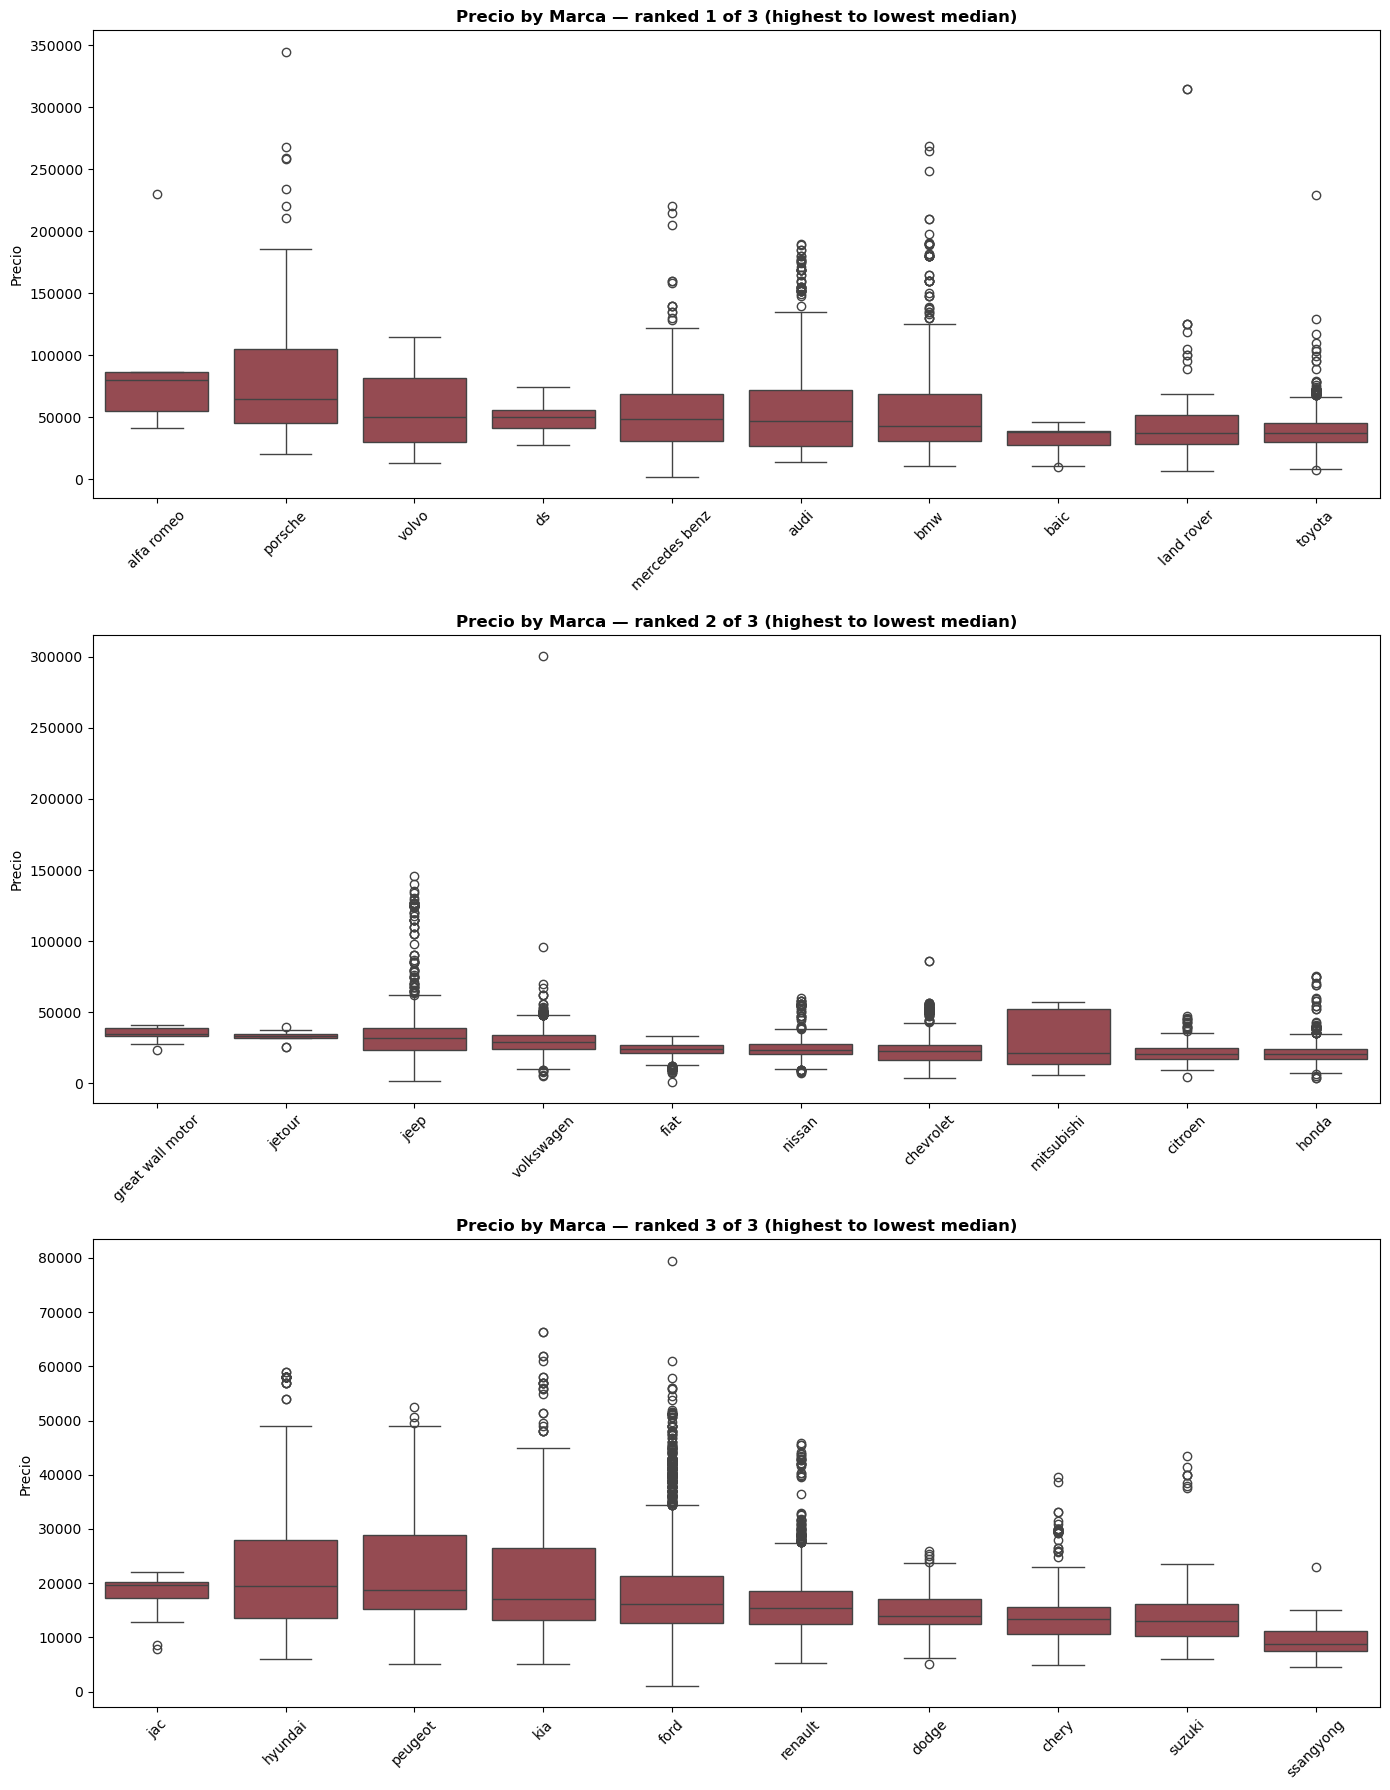

======================== Outliers por Modelo ========================
Filtered out 41 categories with fewer than 15 rows.
Plotting 90 categories split into 4 charts.


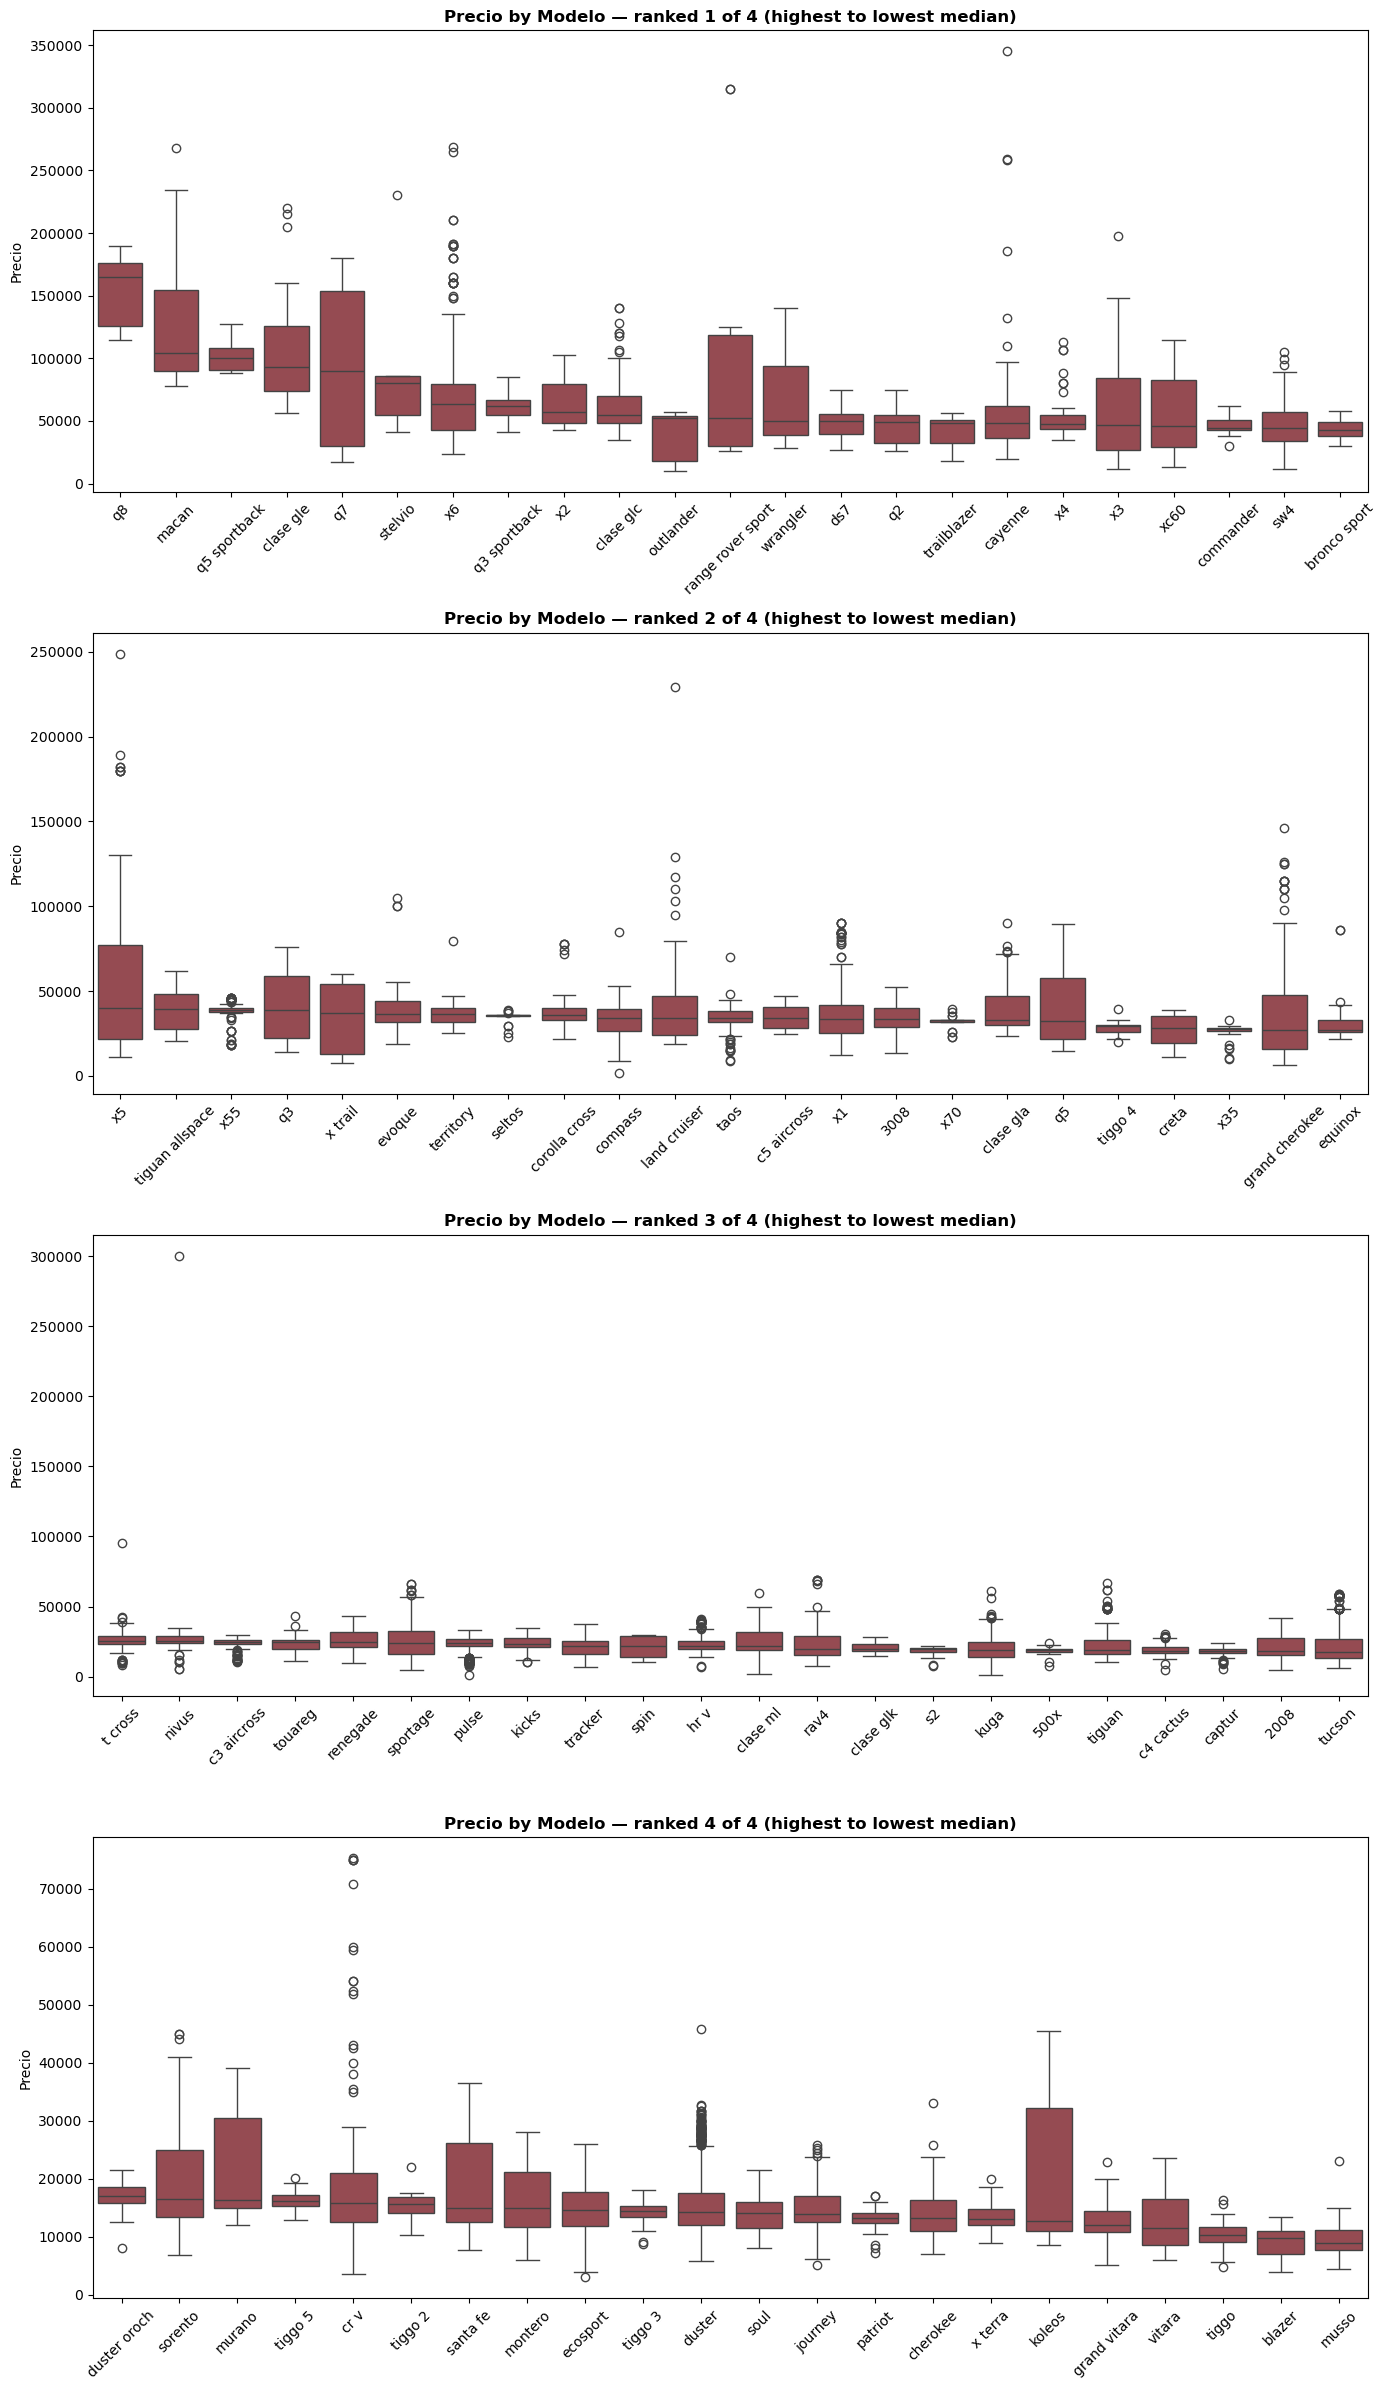

In [208]:
print("======================== Outliers por Marca ========================")
visual.plot_outliers_by_category(dataset_processed, "Marca", min_count=10, n_splits=3)
print("======================== Outliers por Modelo ========================")
visual.plot_outliers_by_category(dataset_processed, "Modelo", min_count=15, n_splits=4)

Durante el análisis de valores extremos se detectó una publicación de un Volkswagen Nivus con un precio cercano a los 300.000 USD, valor que resulta poco consistente con el rango habitual de ese modelo. Este tipo de observaciones puede afectar de forma considerable el entrenamiento y la evaluación del modelo.

Por este motivo, se decidió aplicar criterios de validación de precios diferenciados según el tipo de marca. En particular, se definieron rangos más amplios para marcas que incluyen modelos de alta gama y rangos más restrictivos para el resto, con el objetivo de detectar posibles errores de carga sin eliminar automáticamente vehículos premium cuyo precio elevado puede ser razonable.

In [209]:
PREMIUM_BRANDS = [
    "audi", "bmw", "mercedes benz", "porsche",
    "land rover", "volvo", "alfa romeo"
]

In [210]:
mask = ~dataset_processed["Marca"].isin(PREMIUM_BRANDS)
dataset_processed.loc[mask, "Precio"] = (dataset_processed.loc[mask, "Precio"].clip(lower=1000, upper=150_000))

In [211]:
# Save preprocessed dataset
dataset_processed = dataset_processed.copy()
dataset_processed.to_csv("../data/dataset_pp.csv", index = False)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Data Splitting
</h3>

Una vez terminadas las transformaciones y la recuperación de información desde texto, se separa el dataset en entrenamiento y validación (80% - 20%)

El split se realiza estratificando por `Marca`, ya que esta variable tiene una distribución desigual y suponemos    que está fuertemente relacionada con el precio. Mantener proporciones similares de marcas en train y validation ayuda a que ambos conjuntos sean más comparables.

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Stratified by Brand
</div>

In [212]:
X_pp = dataset_processed.drop(columns = [TARGET])
y_pp = dataset_processed[TARGET]

In [213]:
train_set, val_set = split.train_val_split_stratified(X_pp, y_pp, stratify_by = X_pp["Marca"], train_size = 0.80)

X_train, y_train = train_set
X_val, y_val = val_set

In [214]:
# Split check
split.split_size_summary(X_train, X_val).style.hide(axis = "index")

split,rows,percentage
train,14579,80.000000
validation,3644,20.000000


In [215]:
X_train = X_train.copy()
X_val = X_val.copy()

X_train.to_csv("../data/X_train.csv", index = False)
X_val.to_csv("../data/X_val.csv", index = False)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Pre-One Hot Analysis
</h3>

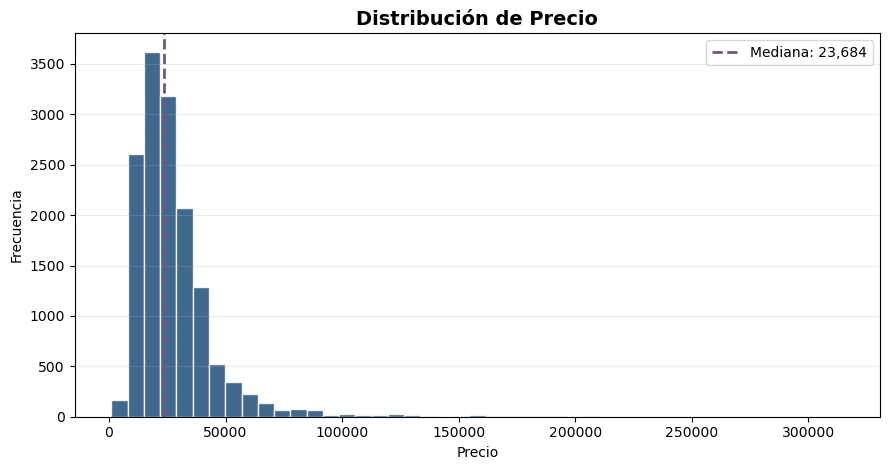

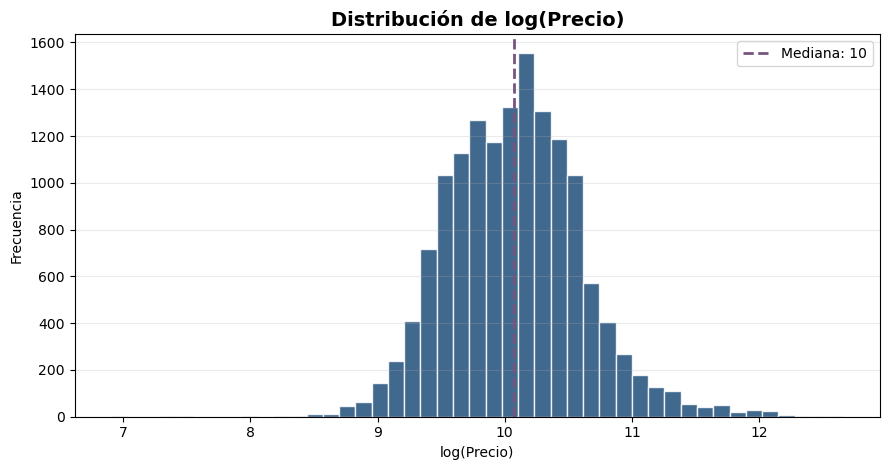

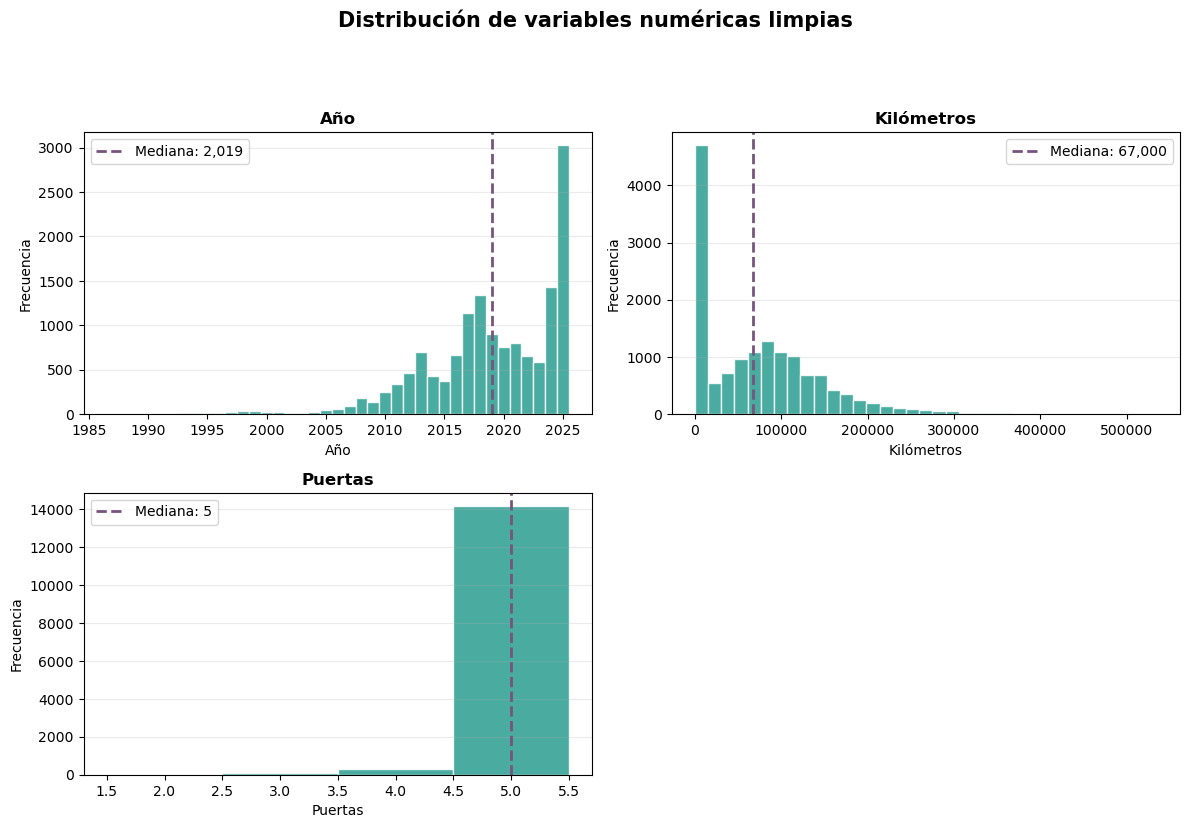

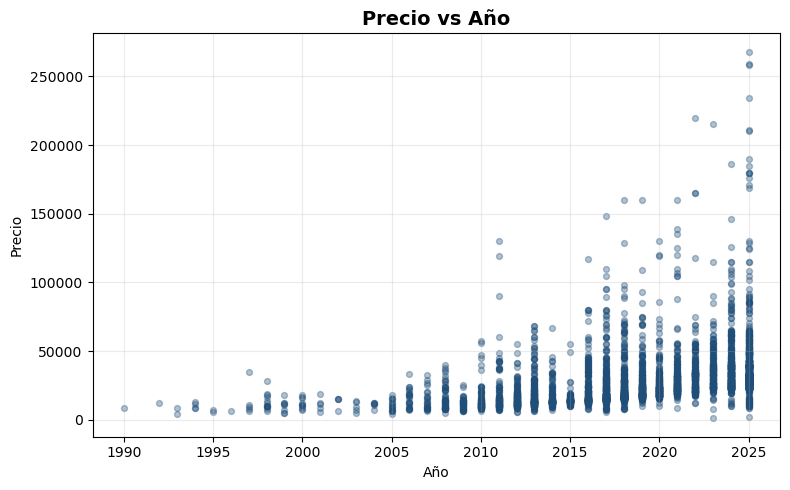

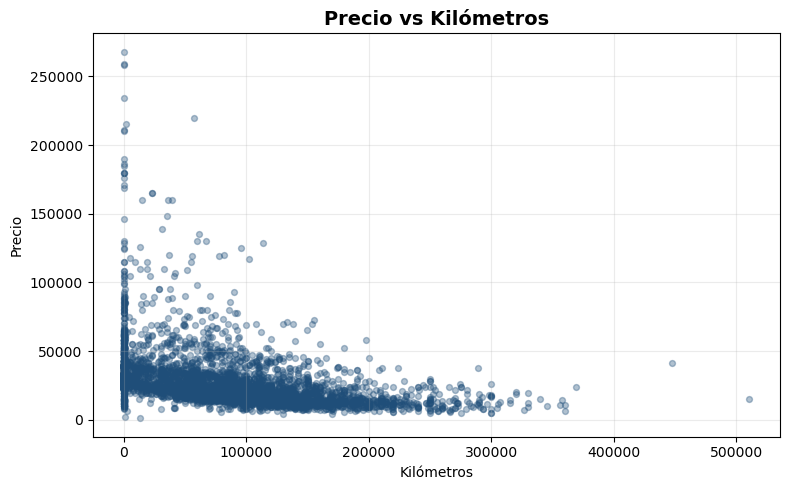

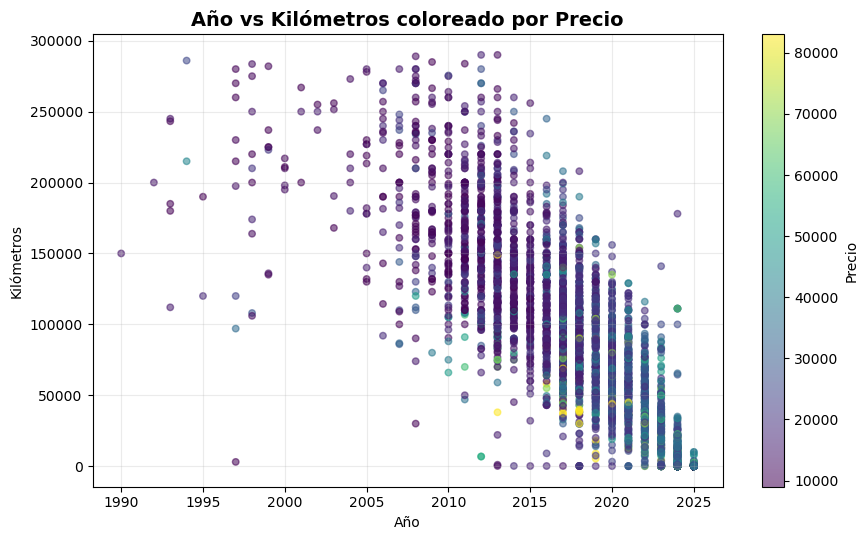

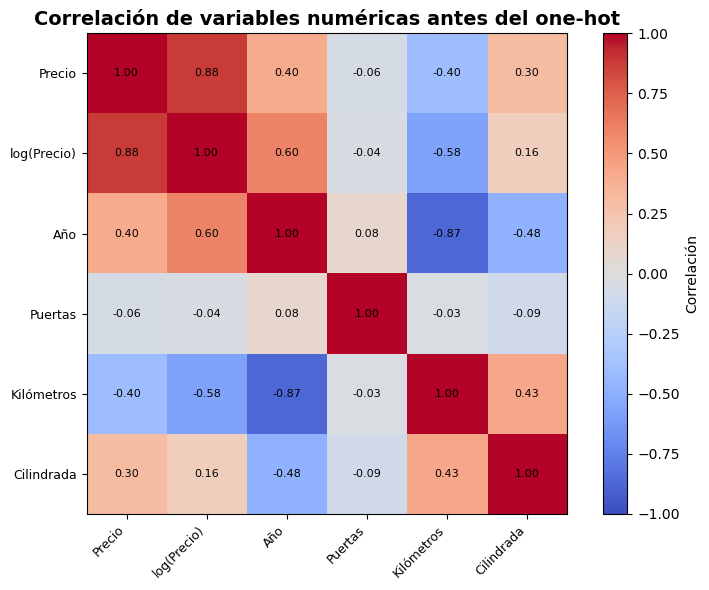

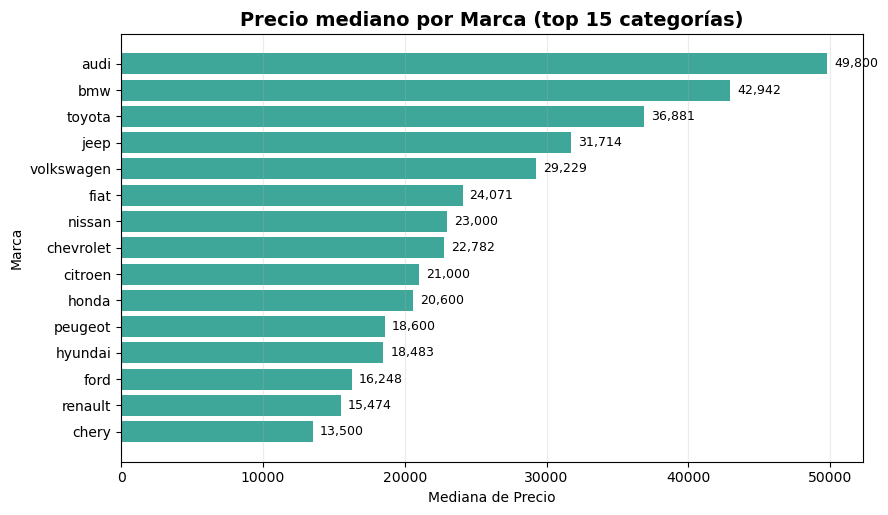

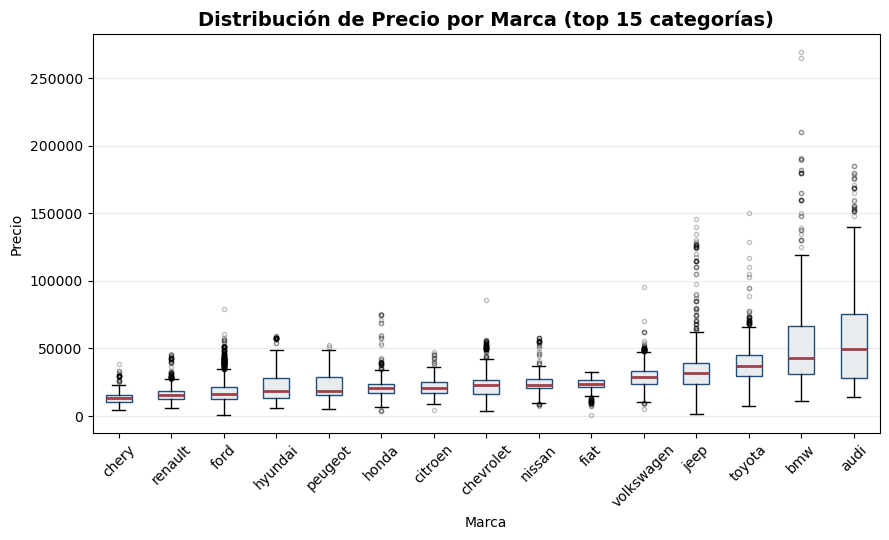

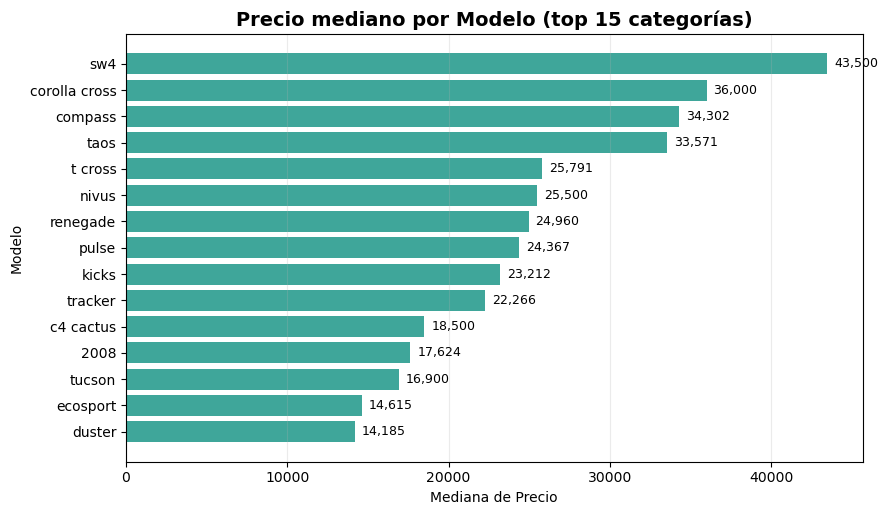

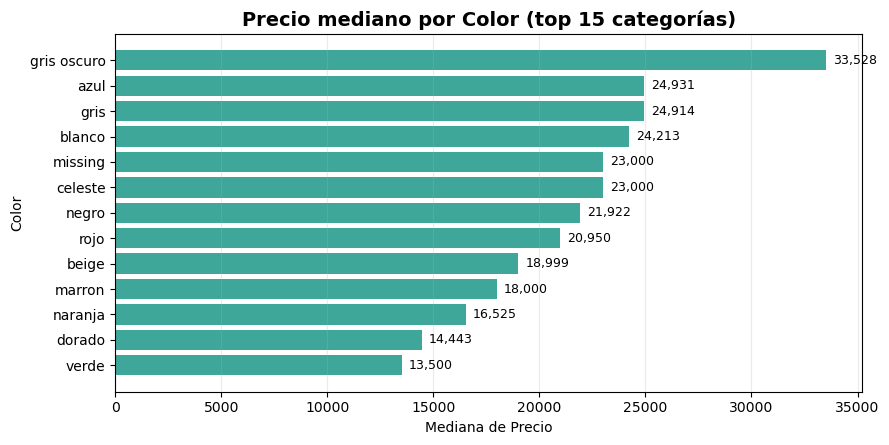

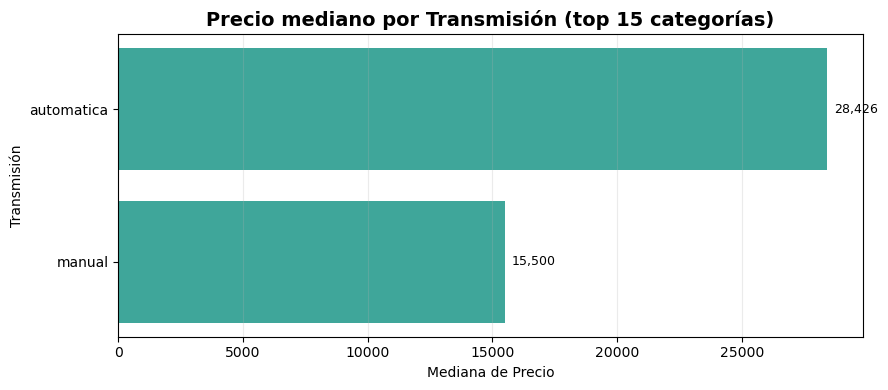

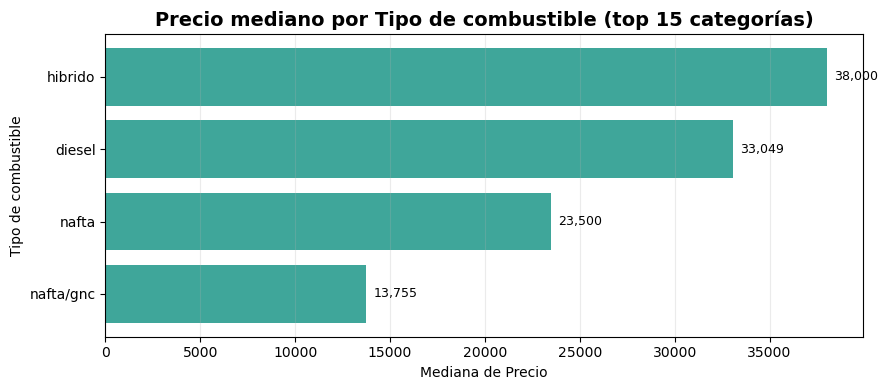

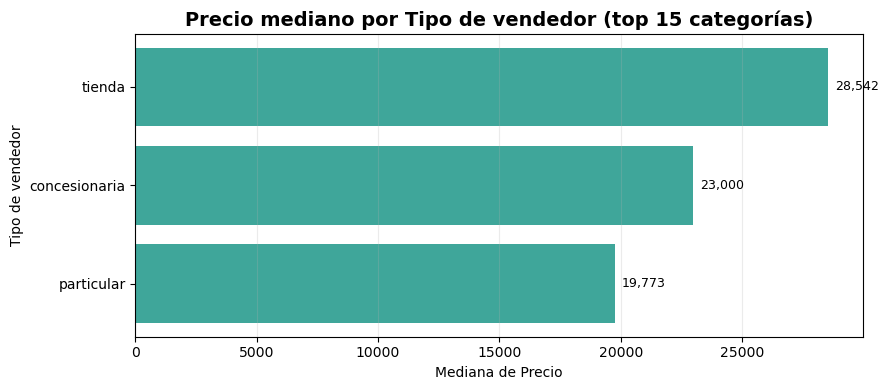

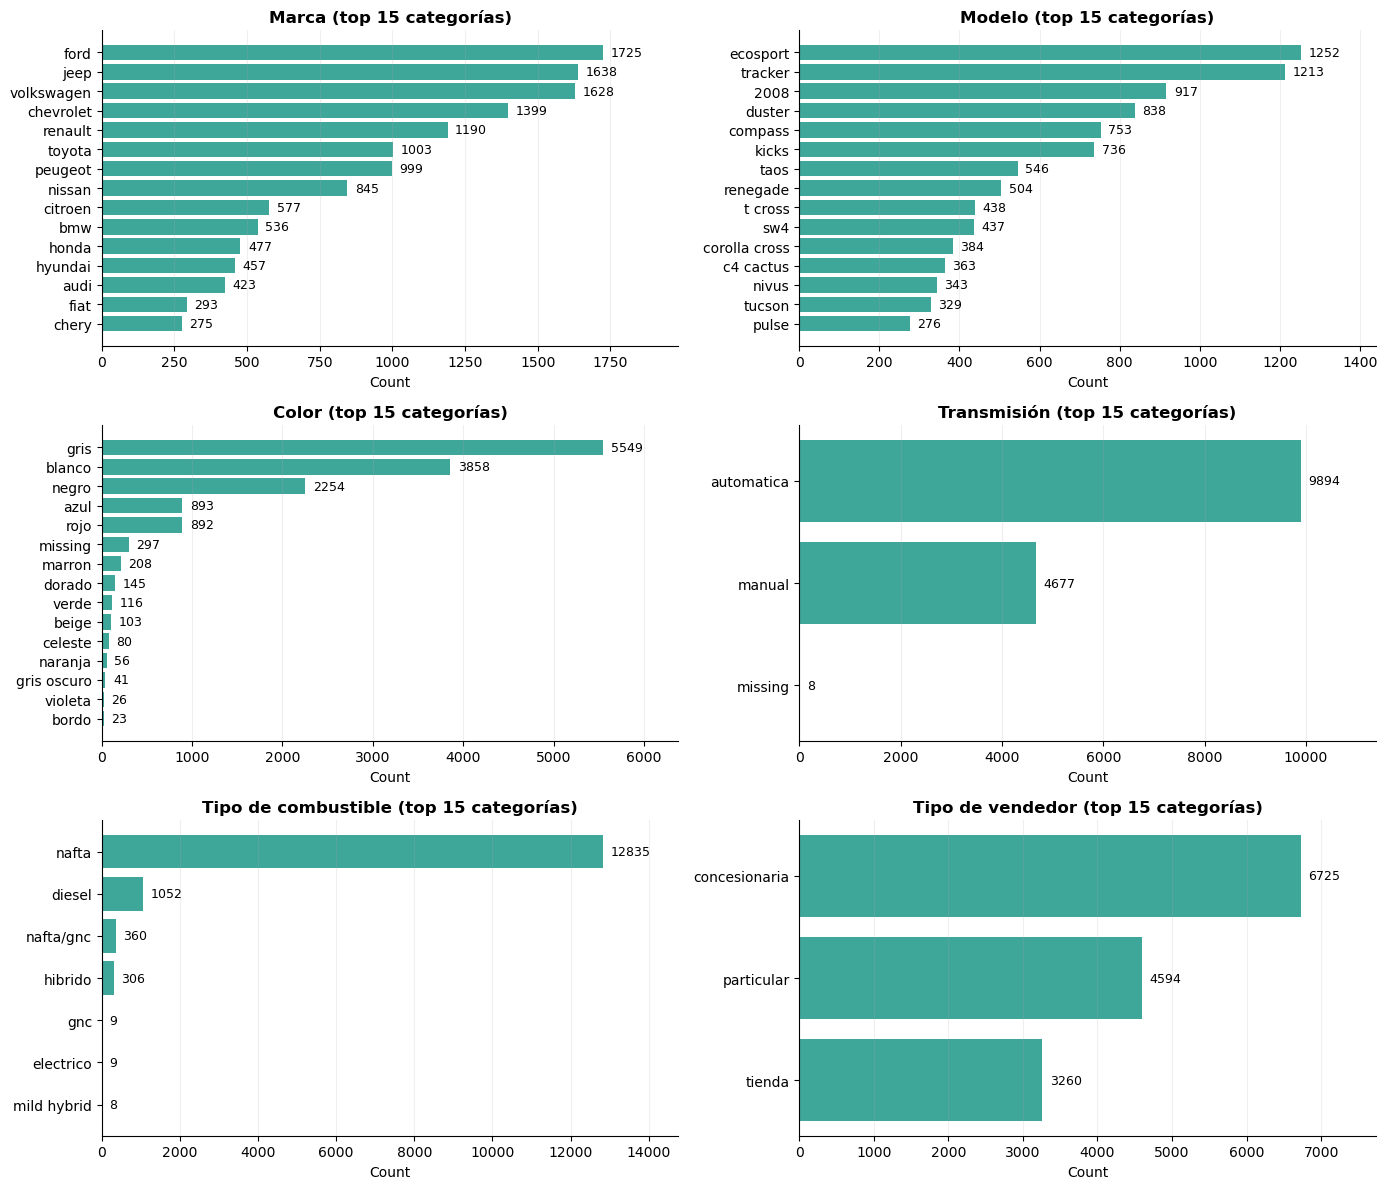

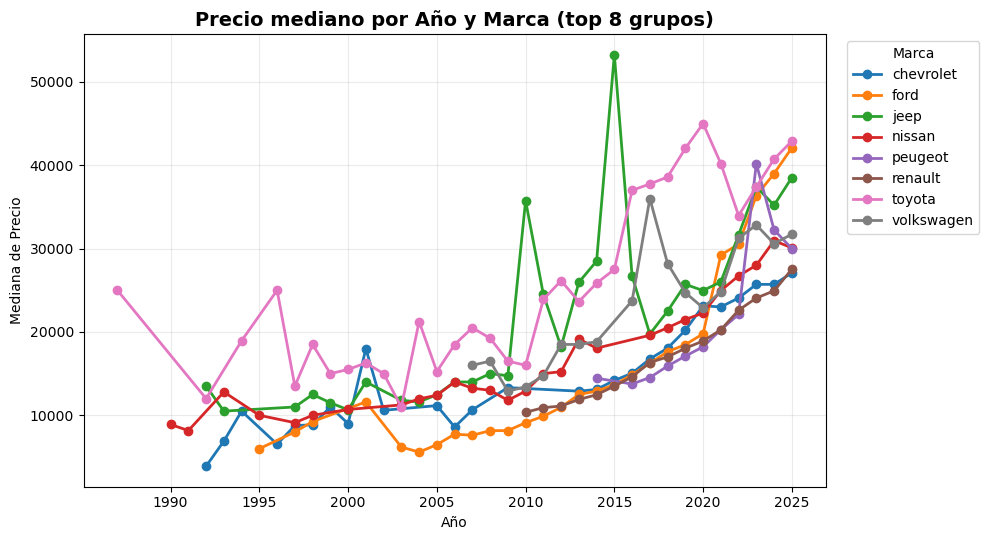

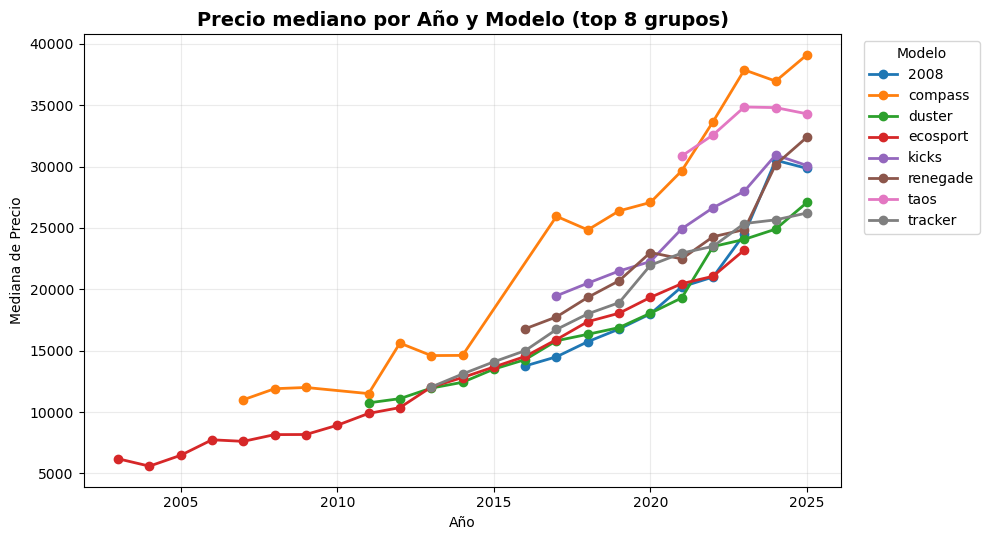

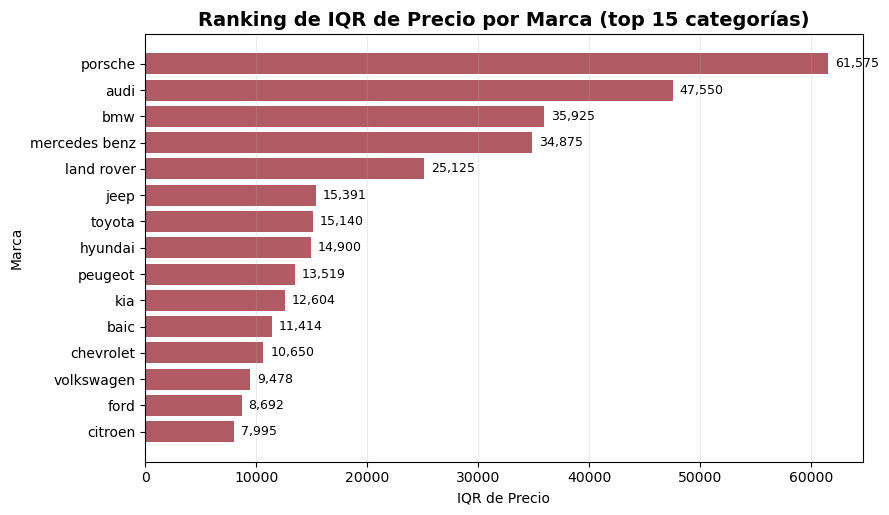

,Marca,count,q1,q3,iqr
0,porsche,54,47175.000000,108750.000000,61575.000000
1,audi,423,27900.000000,75450.000000,47550.000000
2,bmw,536,31000.000000,66925.000000,35925.000000
3,mercedes benz,226,30125.000000,65000.000000,34875.000000
4,land rover,52,26875.000000,52000.000000,25125.000000
5,jeep,1638,23609.149524,39000.000000,15390.850476
6,toyota,1003,29809.640774,44950.000000,15140.359226
7,hyundai,457,13000.000000,27900.000000,14900.000000
8,peugeot,999,15302.425545,28821.000921,13518.575376
9,kia,232,13239.177157,25842.953638,12603.776481


In [216]:
train_pre_onehot = visual.build_plot_dataset(X_train, y_train)

visual.plot_price_distribution(train_pre_onehot)
visual.plot_price_distribution(train_pre_onehot, log_transform=True)

visual.plot_clean_numeric_distributions(train_pre_onehot)

visual.plot_price_vs_numeric(train_pre_onehot, x_col="Año", sample_size=5000)
visual.plot_price_vs_numeric(train_pre_onehot, x_col="Kilómetros", sample_size=5000)

visual.plot_year_kilometers_price_scatter(train_pre_onehot, sample_size=5000)

visual.plot_numeric_correlation_heatmap(
    train_pre_onehot,
    feature_type="numeric",
    title="Correlación de variables numéricas antes del one-hot",
)

visual.plot_median_price_by_category(train_pre_onehot, "Marca", top_n=15, min_count=50)
visual.plot_price_boxplot_by_category(train_pre_onehot, "Marca", top_n=15, min_count=50)

visual.plot_median_price_by_category(train_pre_onehot, "Modelo", top_n=15, min_count=80)
visual.plot_median_price_by_category(train_pre_onehot, "Color", top_n=15, min_count=30)

visual.plot_median_price_by_category(train_pre_onehot, "Transmisión", min_count=30)
visual.plot_median_price_by_category(train_pre_onehot, "Tipo de combustible", min_count=30)
visual.plot_median_price_by_category(train_pre_onehot, "Tipo de vendedor", min_count=30)

visual.plot_category_frequency_after_cleaning(
    train_pre_onehot,
    columns=["Marca", "Modelo", "Color", "Transmisión", "Tipo de combustible", "Tipo de vendedor"],
    top_n=15,
)

visual.plot_median_price_by_year_lines(train_pre_onehot, group_col="Marca", top_n=8, min_count=150)
visual.plot_median_price_by_year_lines(train_pre_onehot, group_col="Modelo", top_n=8, min_count=120)

brand_iqr = visual.plot_iqr_ranking_by_category(
    train_pre_onehot,
    category_col="Marca",
    top_n=15,
    min_count=50,
)

brand_iqr

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
One Hot Encoding
</h3>

Después del split, se aplica one-hot encoding a las variables categóricas. El encoder se ajusta sobre el conjunto de entrenamiento y luego se aplica al conjunto de validación usando las mismas categorías aprendidas.

Este orden evita que el conjunto de validación influya en la definición de las columnas dummy. De esta forma, el preprocesamiento respeta la separación entre train y validation.

In [217]:
categorical_cols_to_encode = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión"
]

X_train_encoded, categories_map = prep.one_hot_encoding(
    X_train,
    categorical_cols = categorical_cols_to_encode,
    train = True,
    binary_missing_cols=["Con cámara de retroceso"]
)

X_val_encoded = prep.one_hot_encoding(
    X_val,
    categorical_cols=categorical_cols_to_encode,
    train=False,
    categories_map=categories_map,
    binary_missing_cols=["Con cámara de retroceso"],
)

In [218]:
X_train_encoded = X_train_encoded.copy()
X_val_encoded = X_val_encoded.copy()

X_train_encoded.to_csv("../data/X_train_pp.csv", index = False)
X_val_encoded.to_csv("../data/X_val_pp.csv", index = False)

y_train.to_csv("../data/y_train.csv", index = False)
y_val.to_csv("../data/y_val.csv", index = False)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Checking preprocessed dataset
</h3>

In [219]:
display(eda.missing_values_summary(X_train_encoded))

,column,missing_count,missing_percentage
0,Cilindrada,18,0.12


In [220]:
display(eda.unique_values_summary(X_train_encoded))

,column,unique_values,unique_pct
6,Descripción,9965,68.35
5,Título,1978,13.57
4,Kilómetros,1884,12.92
1,Versión,1853,12.71
7,Cilindrada,43,0.29
...,...,...,...
213,Tipo de combustible_nafta,2,0.01
214,Tipo de combustible_nafta/gnc,2,0.01
215,Transmisión_automatica,2,0.01
216,Transmisión_manual,2,0.01


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Post-preprocessing EDA
</h3>

Luego del preprocesamiento, se vuelve a explorar la distribución de las variables principales. Esto permite evaluar cómo quedaron los datos luego de la limpieza y detectar si todavía existen valores extremos que puedan afectar el entrenamiento de los modelos.

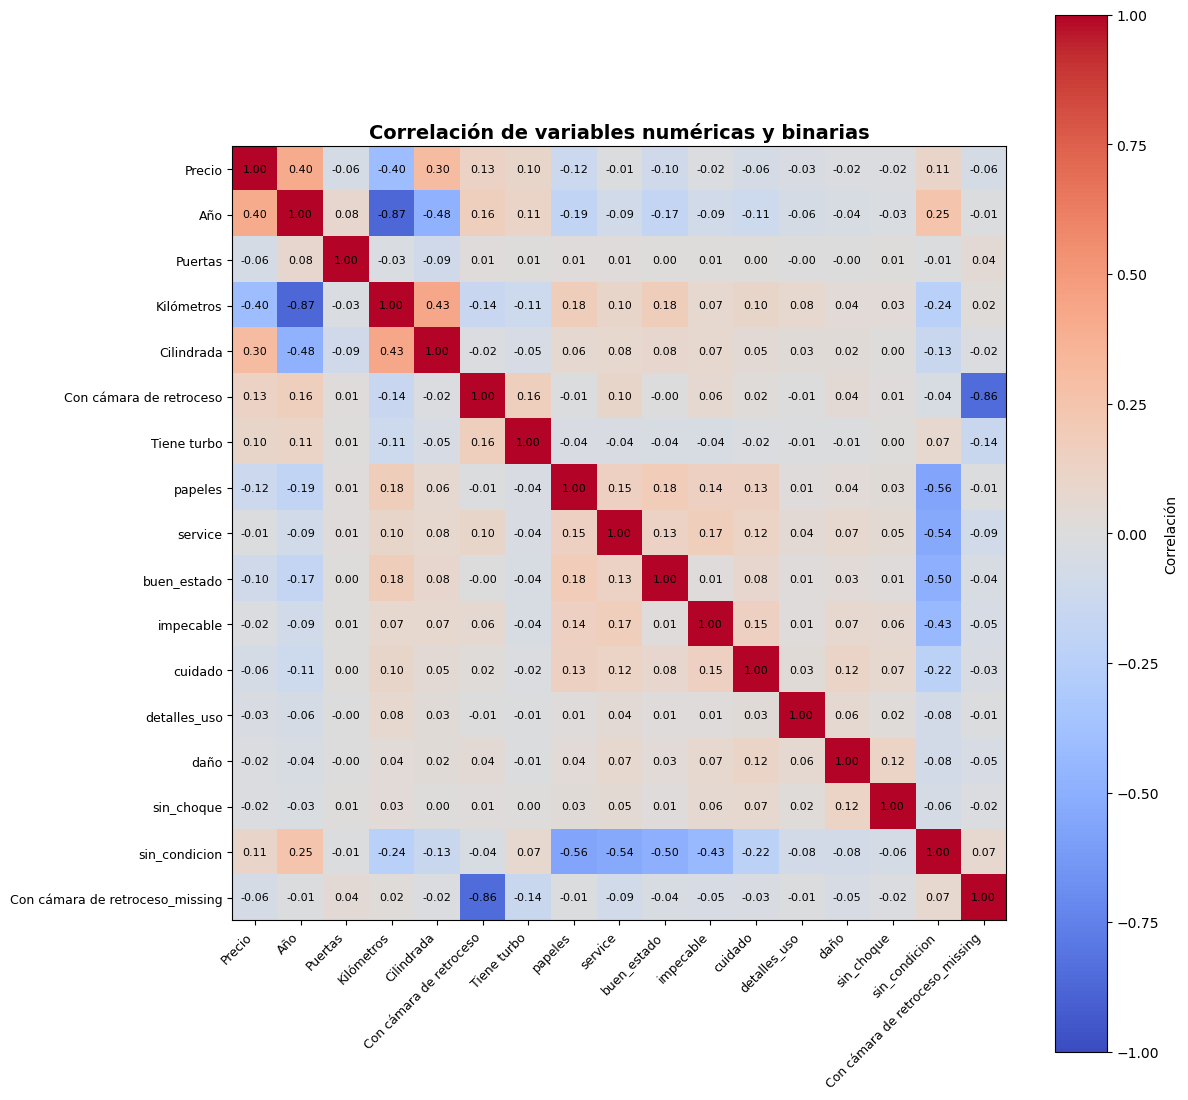

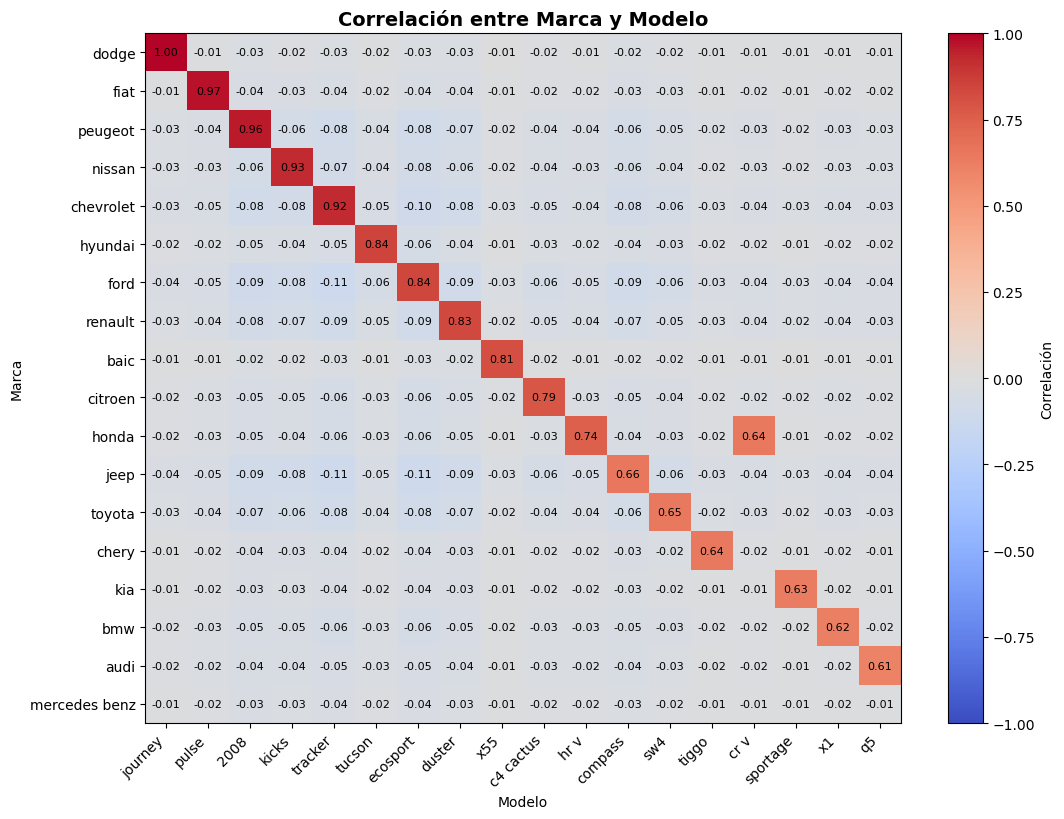

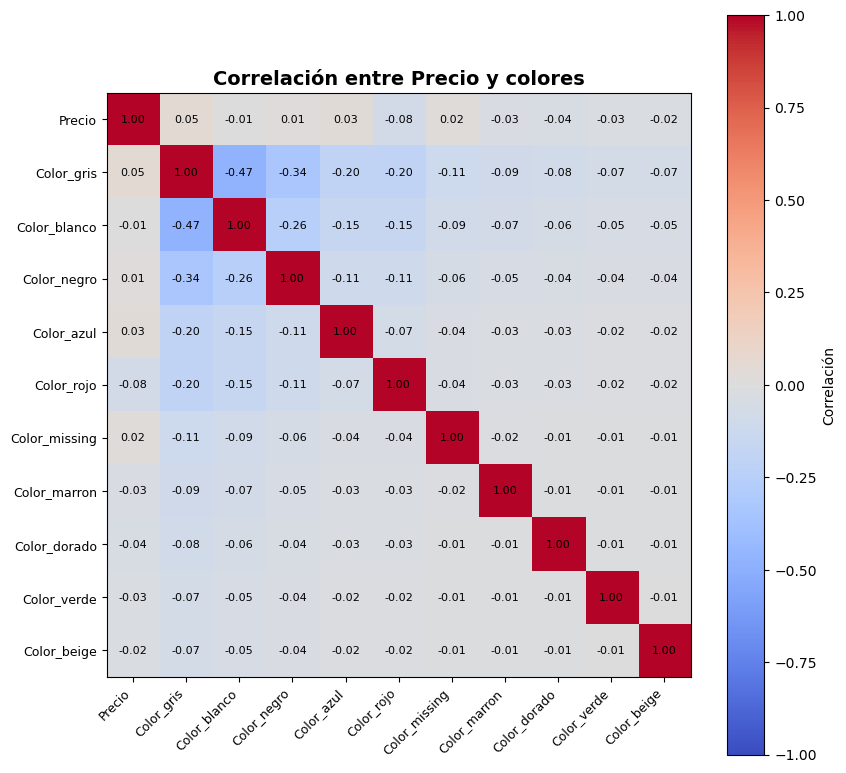

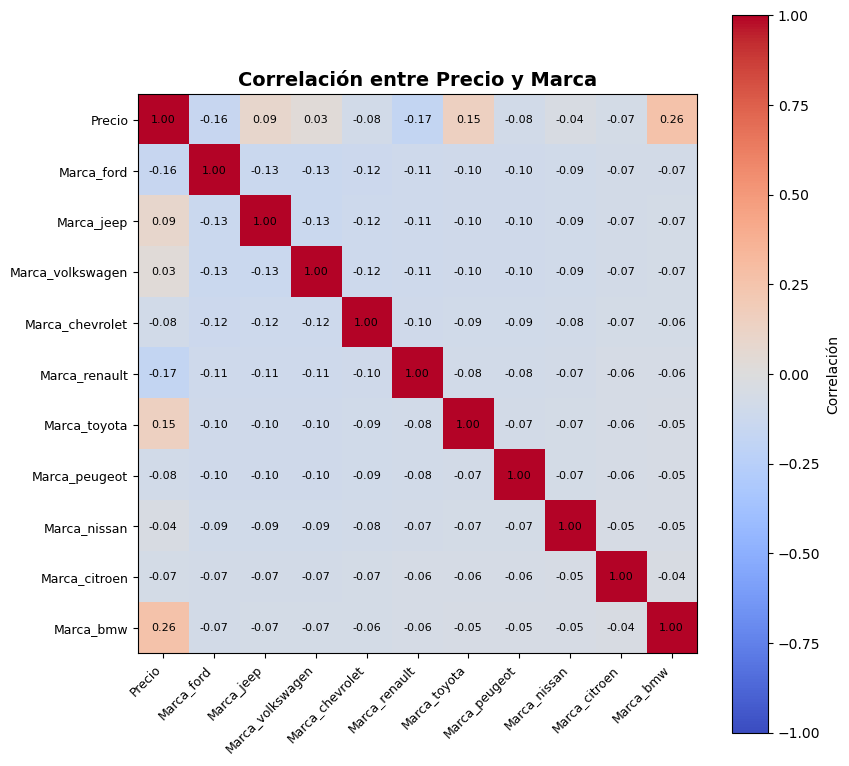

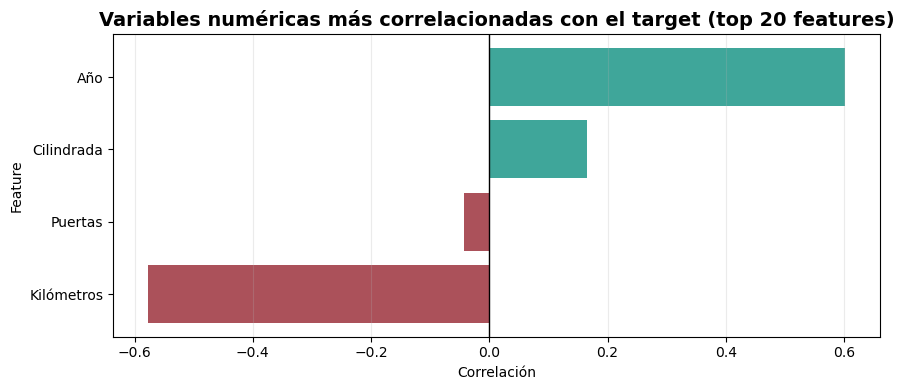

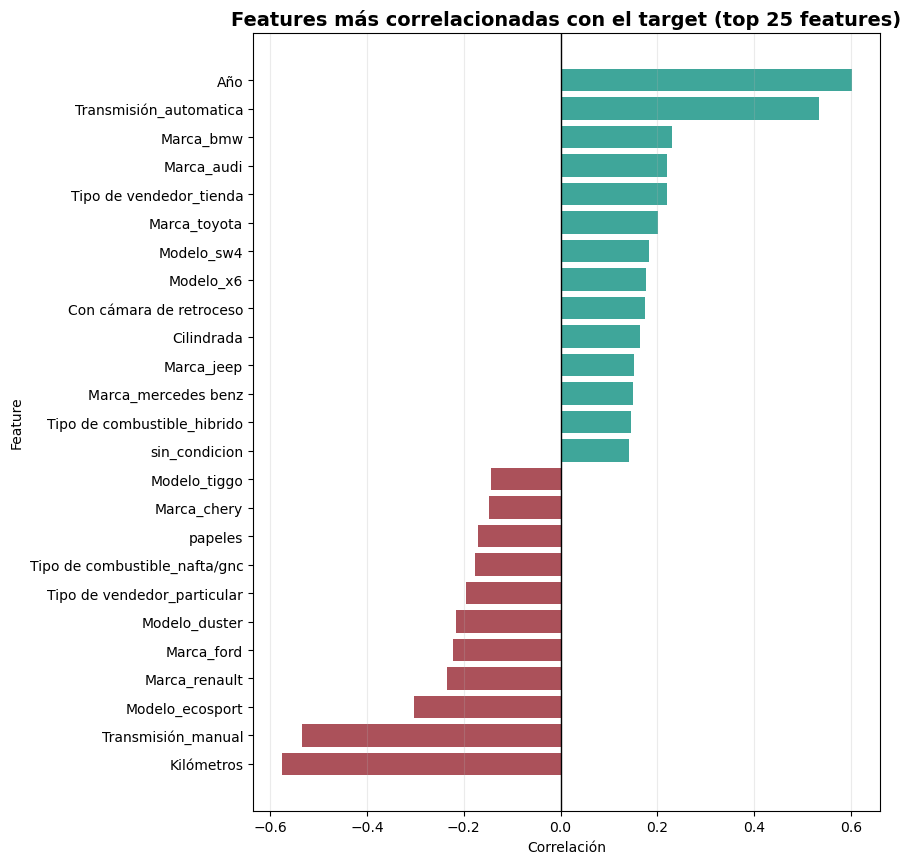

In [221]:
train_encoded = visual.build_plot_dataset(X_train_encoded, y_train)

visual.plot_numeric_and_binary_correlation_heatmap(
    train_encoded,
    title="Correlación de variables numéricas y binarias",
)

color_cols = [col for col in train_encoded.columns if col.startswith("Color_")]
brand_cols = [col for col in train_encoded.columns if col.startswith("Marca_")]

top_color_cols = (
    train_encoded[color_cols]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

top_brand_cols = (
    train_encoded[brand_cols]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

marca_modelo_corr = visual.plot_one_hot_group_correlation_heatmap(
    train_encoded,
    row_prefix="Marca",
    col_prefix="Modelo",
    top_n_pairs=50,
    top_n_rows=18,
    top_n_cols=18,
    min_frequency=0.005,
    title="Correlación entre Marca y Modelo",
    annotate=True,
)


visual.plot_numeric_correlation_heatmap(
    train_encoded,
    numeric_cols=["Precio"] + top_color_cols,
    add_log_price=False,
    include_target=False,
    include_log_target=False,
    title="Correlación entre Precio y colores",
)


visual.plot_numeric_correlation_heatmap(
    train_encoded,
    numeric_cols=["Precio"] + top_brand_cols,
    add_log_price=False,
    include_target=False,
    include_log_target=False,
    title="Correlación entre Precio y Marca",
)

numeric_corr_table = visual.plot_top_target_correlations(
    train_encoded,
    feature_type="numeric",
    top_n=20,
    title="Variables numéricas más correlacionadas con el target",
)

all_corr_table = visual.plot_top_target_correlations(
    train_encoded,
    feature_type="both",
    top_n=25,
    title="Features más correlacionadas con el target",
)